In [1]:
#Import libraries, set plot style, and define per-model CSV file paths
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (12, 6)

DATA_DIR = 'final_data/'
MODEL_FILES = {
    'llama': (f'{DATA_DIR}llama_label0.csv', f'{DATA_DIR}llama_label1.csv'),
    'phi':   (f'{DATA_DIR}phi_label0.csv',   f'{DATA_DIR}phi_label1.csv'),
    'qwen':  (f'{DATA_DIR}qwen_label0.csv',  f'{DATA_DIR}qwen_label1.csv'),
}

print('Config loaded ✓')

Config loaded ✓


In [2]:
#Check current matplotlib backend
import matplotlib
print(matplotlib.get_backend())

inline


In [3]:
#Load benign/abuse CSVs for each model and combine into a master DataFrame
model_dfs = {}
all_frames = []

for model_name, (path0, path1) in MODEL_FILES.items():
    df0 = pd.read_csv(path0)
    df1 = pd.read_csv(path1)

    df0['label'] = 0
    df1['label'] = 1
    df0['model_name'] = model_name
    df1['model_name'] = model_name

    combined = pd.concat([df0, df1], ignore_index=True)
    model_dfs[model_name] = combined
    all_frames.append(combined)

    print(f"{model_name:6s} | benign={len(df0):5d} | abuse={len(df1):5d} | total={len(combined):5d}")

df_all = pd.concat(all_frames, ignore_index=True)
df_all['label_str'] = df_all['label'].map({0: 'benign', 1: 'abuse'})

print(f"\nMaster df: {df_all.shape[0]:,} rows x {df_all.shape[1]} cols")
print(f"Label balance: {df_all['label'].value_counts().to_dict()}")

llama  | benign=  952 | abuse=  337 | total= 1289
phi    | benign=  844 | abuse=  400 | total= 1244
qwen   | benign=  998 | abuse=  400 | total= 1398

Master df: 3,931 rows x 26 cols
Label balance: {0: 2794, 1: 1137}


In [4]:
#Print schema, null counts, and numeric summary statistics
print('=== SCHEMA ===')
print(df_all.dtypes)

print('\n=== NULL COUNTS ===')
nulls = df_all.isnull().sum()
print(nulls[nulls > 0] if nulls.sum() > 0 else 'No nulls ✓')

print('\n=== NUMERIC SUMMARY ===')
numeric_cols = ['latency_s', 'tokens_out', 'tokens_in',
                'power_mean_w', 'power_max_w', 'power_min_w', 'power_std_w',
                'power_auc', 'power_per_token',
                'gpu_util_mean', 'gpu_util_max', 'gpu_util_std',
                'mem_used_mean_gb', 'mem_used_max_gb', 'n_samples']
numeric_cols = [c for c in numeric_cols if c in df_all.columns]

display(df_all[numeric_cols].describe().round(3))

=== SCHEMA ===
label                 int64
request_id              str
model                   str
t_start             float64
t_end               float64
latency_s           float64
tokens_out          float64
tokens_in           float64
prompt_hash             str
prompt_preview          str
endpoint                str
status_code           int64
power_mean_w        float64
power_max_w         float64
power_min_w         float64
power_std_w         float64
power_auc           float64
power_per_token     float64
gpu_util_mean       float64
gpu_util_max        float64
gpu_util_std        float64
mem_used_mean_gb    float64
mem_used_max_gb     float64
n_samples             int64
model_name              str
label_str               str
dtype: object

=== NULL COUNTS ===
tokens_out    16
tokens_in     16
dtype: int64

=== NUMERIC SUMMARY ===


,latency_s,tokens_out,tokens_in,power_mean_w,power_max_w,power_min_w,power_std_w,power_auc,power_per_token,gpu_util_mean,gpu_util_max,gpu_util_std,mem_used_mean_gb,mem_used_max_gb,n_samples
count,3931.000,3915.000,3915.000,3931.000,3931.000,3931.000,3931.000,3931.000,3931.000,3931.000,3931.000,3931.000,3931.000,3931.000,3931.000
mean,2.113,221.414,97.578,229.391,267.232,175.387,35.562,3842.314,149.651,81.604,94.468,23.968,14.960,14.960,20.653
std,7.592,72.115,137.279,52.624,53.024,61.180,25.841,2958.854,2109.417,19.646,19.013,12.051,0.630,0.630,75.096
min,0.011,1.000,5.000,25.268,25.573,24.586,0.000,0.000,0.000,0.000,0.000,0.000,14.114,14.114,1.000
25%,0.855,256.000,20.000,170.785,224.204,133.076,7.772,1246.973,5.154,77.222,99.000,19.352,14.256,14.256,8.000
50%,2.189,256.000,43.000,247.129,292.581,153.191,30.179,5319.579,20.972,88.818,99.000,26.021,14.990,14.990,22.000
75%,2.241,256.000,92.000,261.316,313.275,235.187,62.270,5655.028,22.188,91.818,100.000,32.216,15.681,15.681,22.000
max,120.100,256.000,1125.000,312.785,317.725,309.567,108.530,41448.787,41448.786,99.000,100.000,49.000,15.831,15.872,1190.000


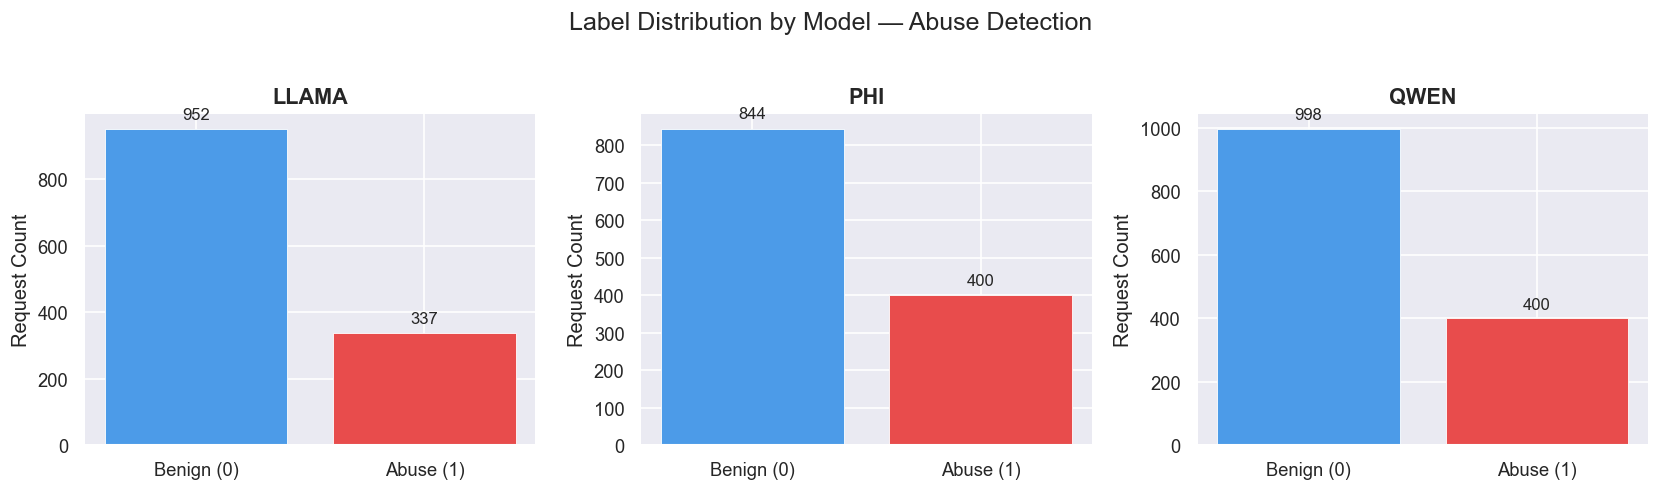

In [5]:
#Bar plot of benign vs abuse request counts per model
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=False)

for ax, (model_name, df) in zip(axes, model_dfs.items()):
    counts = df['label'].value_counts().sort_index()
    bars = ax.bar(['Benign (0)', 'Abuse (1)'], counts.values,
                  color=['#4c9be8', '#e84c4c'], edgecolor='white', linewidth=0.5)
    ax.set_title(f'{model_name.upper()}', fontsize=13, fontweight='bold')
    ax.set_ylabel('Request Count')
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                f'{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=10)

plt.suptitle('Label Distribution by Model — Abuse Detection', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

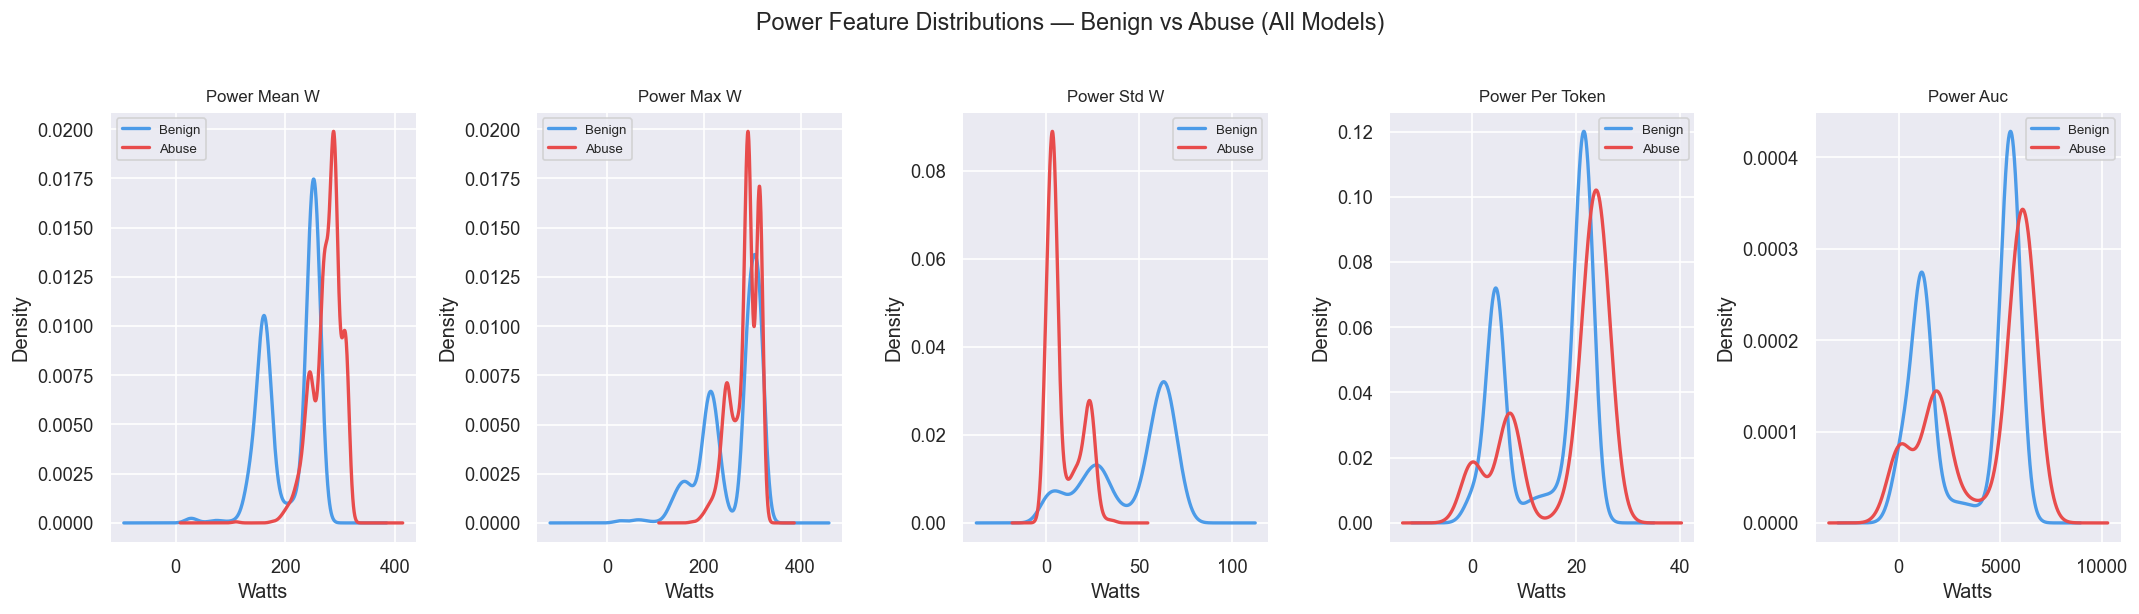


=== MANN-WHITNEY U TEST (power features) ===
Feature                 Benign Mean   Abuse Mean      p-value  Significant
------------------------------------------------------------------------
power_mean_w                210.605      275.554       0.0000   *** p<.001
power_max_w                 259.819      285.449       0.0000   *** p<.001
power_std_w                  46.182        9.466       0.0000   *** p<.001
power_per_token             203.205       18.049       0.0000   *** p<.001
power_auc                  3674.028     4255.852       0.0000   *** p<.001


In [6]:
#KDE plots of power features by label and Mann-Whitney U significance tests
power_features = ['power_mean_w', 'power_max_w', 'power_std_w', 'power_per_token', 'power_auc']
power_features = [c for c in power_features if c in df_all.columns]

fig, axes = plt.subplots(1, len(power_features), figsize=(18, 5))

for ax, feat in zip(axes, power_features):
    for label, color in [(0, '#4c9be8'), (1, '#e84c4c')]:
        subset = df_all[df_all['label'] == label][feat].dropna()
        subset = subset[subset < subset.quantile(0.99)]
        subset.plot.kde(ax=ax, label='Benign' if label==0 else 'Abuse',
                        color=color, linewidth=2)
    ax.set_title(feat.replace('_', ' ').title(), fontsize=10)
    ax.set_xlabel('Watts' if 'w' in feat else '')
    ax.legend(fontsize=8)

plt.suptitle('Power Feature Distributions — Benign vs Abuse (All Models)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print('\n=== MANN-WHITNEY U TEST (power features) ===')
print(f'{"Feature":<22} {"Benign Mean":>12} {"Abuse Mean":>12} {"p-value":>12} {"Significant":>12}')
print('-' * 72)
for feat in power_features:
    g0 = df_all[df_all['label']==0][feat].dropna()
    g1 = df_all[df_all['label']==1][feat].dropna()
    stat, p = stats.mannwhitneyu(g0, g1, alternative='two-sided')
    sig = '*** p<.001' if p < 0.001 else ('** p<.01' if p < 0.01 else ('* p<.05' if p < 0.05 else 'ns'))
    print(f'{feat:<22} {g0.mean():>12.3f} {g1.mean():>12.3f} {p:>12.4f} {sig:>12}')

Saved: figures/fig_power_kde.pdf / .png


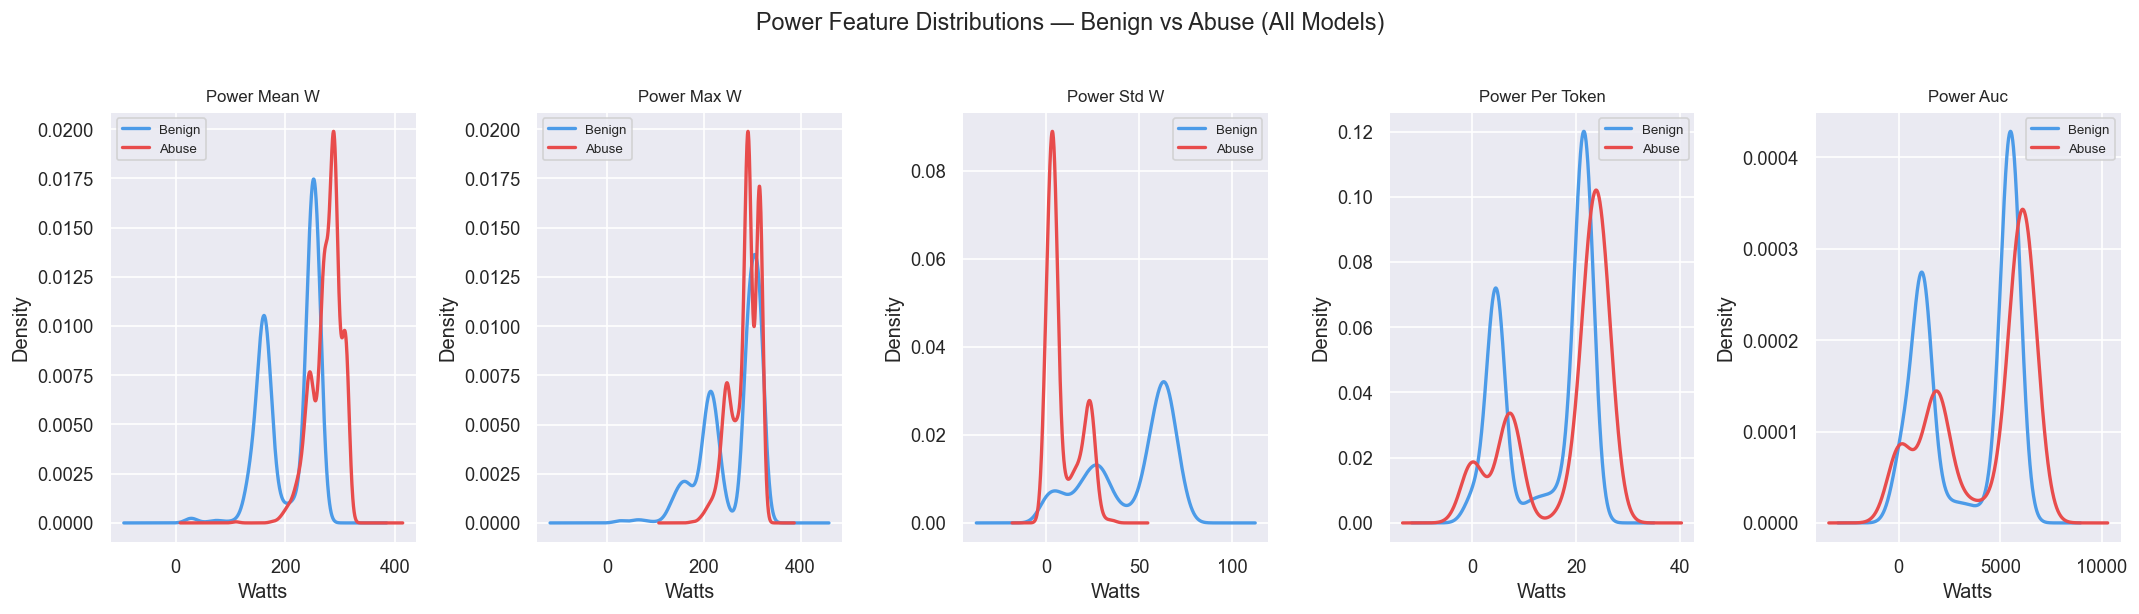

In [7]:
#Save power KDE plots to PDF/PNG and display
import os
import matplotlib.pyplot as plt
from IPython.display import display

os.makedirs('figures', exist_ok=True)

power_features = ['power_mean_w', 'power_max_w', 'power_std_w', 'power_per_token', 'power_auc']
power_features = [c for c in power_features if c in df_all.columns]

plt.close('all')
fig, axes = plt.subplots(1, len(power_features), figsize=(18, 5))

for ax, feat in zip(axes, power_features):
    for label, color in [(0, '#4c9be8'), (1, '#e84c4c')]:
        subset = df_all[df_all['label'] == label][feat].dropna()
        subset = subset[subset < subset.quantile(0.99)]
        subset.plot.kde(ax=ax, label='Benign' if label == 0 else 'Abuse',
                        color=color, linewidth=2)
    ax.set_title(feat.replace('_', ' ').title(), fontsize=10)
    ax.set_xlabel('Watts' if 'w' in feat else '')
    ax.legend(fontsize=8)

plt.suptitle('Power Feature Distributions — Benign vs Abuse (All Models)', fontsize=14, y=1.02)
plt.tight_layout()

fig.savefig('figures/fig_power_kde.pdf', bbox_inches='tight', dpi=300)
fig.savefig('figures/fig_power_kde.png', bbox_inches='tight', dpi=300)
print("Saved: figures/fig_power_kde.pdf / .png")

display(fig)
plt.close(fig)

In [8]:
#Diagnose axes grid collision, missing columns, NaN counts, and sample sizes per model
PLOT_COLS = ['latency_s', 'tokens_out', 'power_mean_w', 'gpu_util_mean', 'power_per_token']

print('=' * 65)
print('DIAG 1 — model_dfs keys and row order')
print('=' * 65)
for row_idx, (model_name, df) in enumerate(model_dfs.items()):
    print(f'  row_idx={row_idx}  model={model_name}  shape={df.shape}')
    resolved = f'axes[{row_idx}][col]' if row_idx < 2 else f'axes[1][col]  ← COLLISION — overwrites row_idx=1 (phi)'
    print(f'           axes mapping → {resolved}')

print()
print('=' * 65)
print('DIAG 2 — Column availability in each model df')
print('=' * 65)
for model_name, df in model_dfs.items():
    for col in PLOT_COLS:
        present = col in df.columns
        status = '✓' if present else '✗ MISSING'
        print(f'  {model_name:6s} | {col:<20} | {status}')

print()
print('=' * 65)
print('DIAG 3 — NaN counts in plot columns (per model)')
print('=' * 65)
for model_name, df in model_dfs.items():
    nan_counts = df[PLOT_COLS].isnull().sum()
    has_nans = nan_counts[nan_counts > 0]
    if has_nans.empty:
        print(f'  {model_name:6s} | no NaNs in plot columns ✓')
    else:
        print(f'  {model_name:6s} | NaNs found: {has_nans.to_dict()}  ← may prevent scatter render')

print()
print('=' * 65)
print('DIAG 4 — Sample sizes per model/label (min 1 required to plot)')
print('=' * 65)
for model_name, df in model_dfs.items():
    for label in [0, 1]:
        n = len(df[df['label'] == label])
        flag = '' if n > 0 else '  ← EMPTY — scatter will silently skip'
        print(f'  {model_name:6s} | label={label} | n={n:6,}{flag}')

print()
print('=' * 65)
print('DIAG 5 — Value ranges for phi (spot outliers that collapse scatter)')
print('=' * 65)
if 'phi' in model_dfs:
    phi_df = model_dfs['phi']
    for col in PLOT_COLS:
        if col in phi_df.columns:
            s = phi_df[col].dropna()
            print(f'  phi | {col:<20} | min={s.min():.3f}  max={s.max():.3f}  '
                  f'mean={s.mean():.3f}  nulls={phi_df[col].isnull().sum()}')
else:
    print('  phi key NOT found in model_dfs  ← root cause')

print()
print('=' * 65)
print('DIAG 6 — Root cause summary')
print('=' * 65)
n_models = len(model_dfs)
if n_models > 2:
    print(f'  ⚠ model_dfs has {n_models} models but Cell 6 uses a 2-row axes grid.')
    print(f'    model at row_idx=2+ maps to axes[1], overwriting the phi row.')
    print(f'    FIX: change plt.subplots(2, 3) → plt.subplots({n_models}, 3) in Cell 6.')
else:
    print(f'  Grid size matches model count ({n_models}). Issue is likely NaN or empty subset — see DIAG 3/4.')

DIAG 1 — model_dfs keys and row order
  row_idx=0  model=llama  shape=(1289, 25)
           axes mapping → axes[0][col]
  row_idx=1  model=phi  shape=(1244, 25)
           axes mapping → axes[1][col]
  row_idx=2  model=qwen  shape=(1398, 25)
           axes mapping → axes[1][col]  ← COLLISION — overwrites row_idx=1 (phi)

DIAG 2 — Column availability in each model df
  llama  | latency_s            | ✓
  llama  | tokens_out           | ✓
  llama  | power_mean_w         | ✓
  llama  | gpu_util_mean        | ✓
  llama  | power_per_token      | ✓
  phi    | latency_s            | ✓
  phi    | tokens_out           | ✓
  phi    | power_mean_w         | ✓
  phi    | gpu_util_mean        | ✓
  phi    | power_per_token      | ✓
  qwen   | latency_s            | ✓
  qwen   | tokens_out           | ✓
  qwen   | power_mean_w         | ✓
  qwen   | gpu_util_mean        | ✓
  qwen   | power_per_token      | ✓

DIAG 3 — NaN counts in plot columns (per model)
  llama  | no NaNs in plot columns ✓
  ph

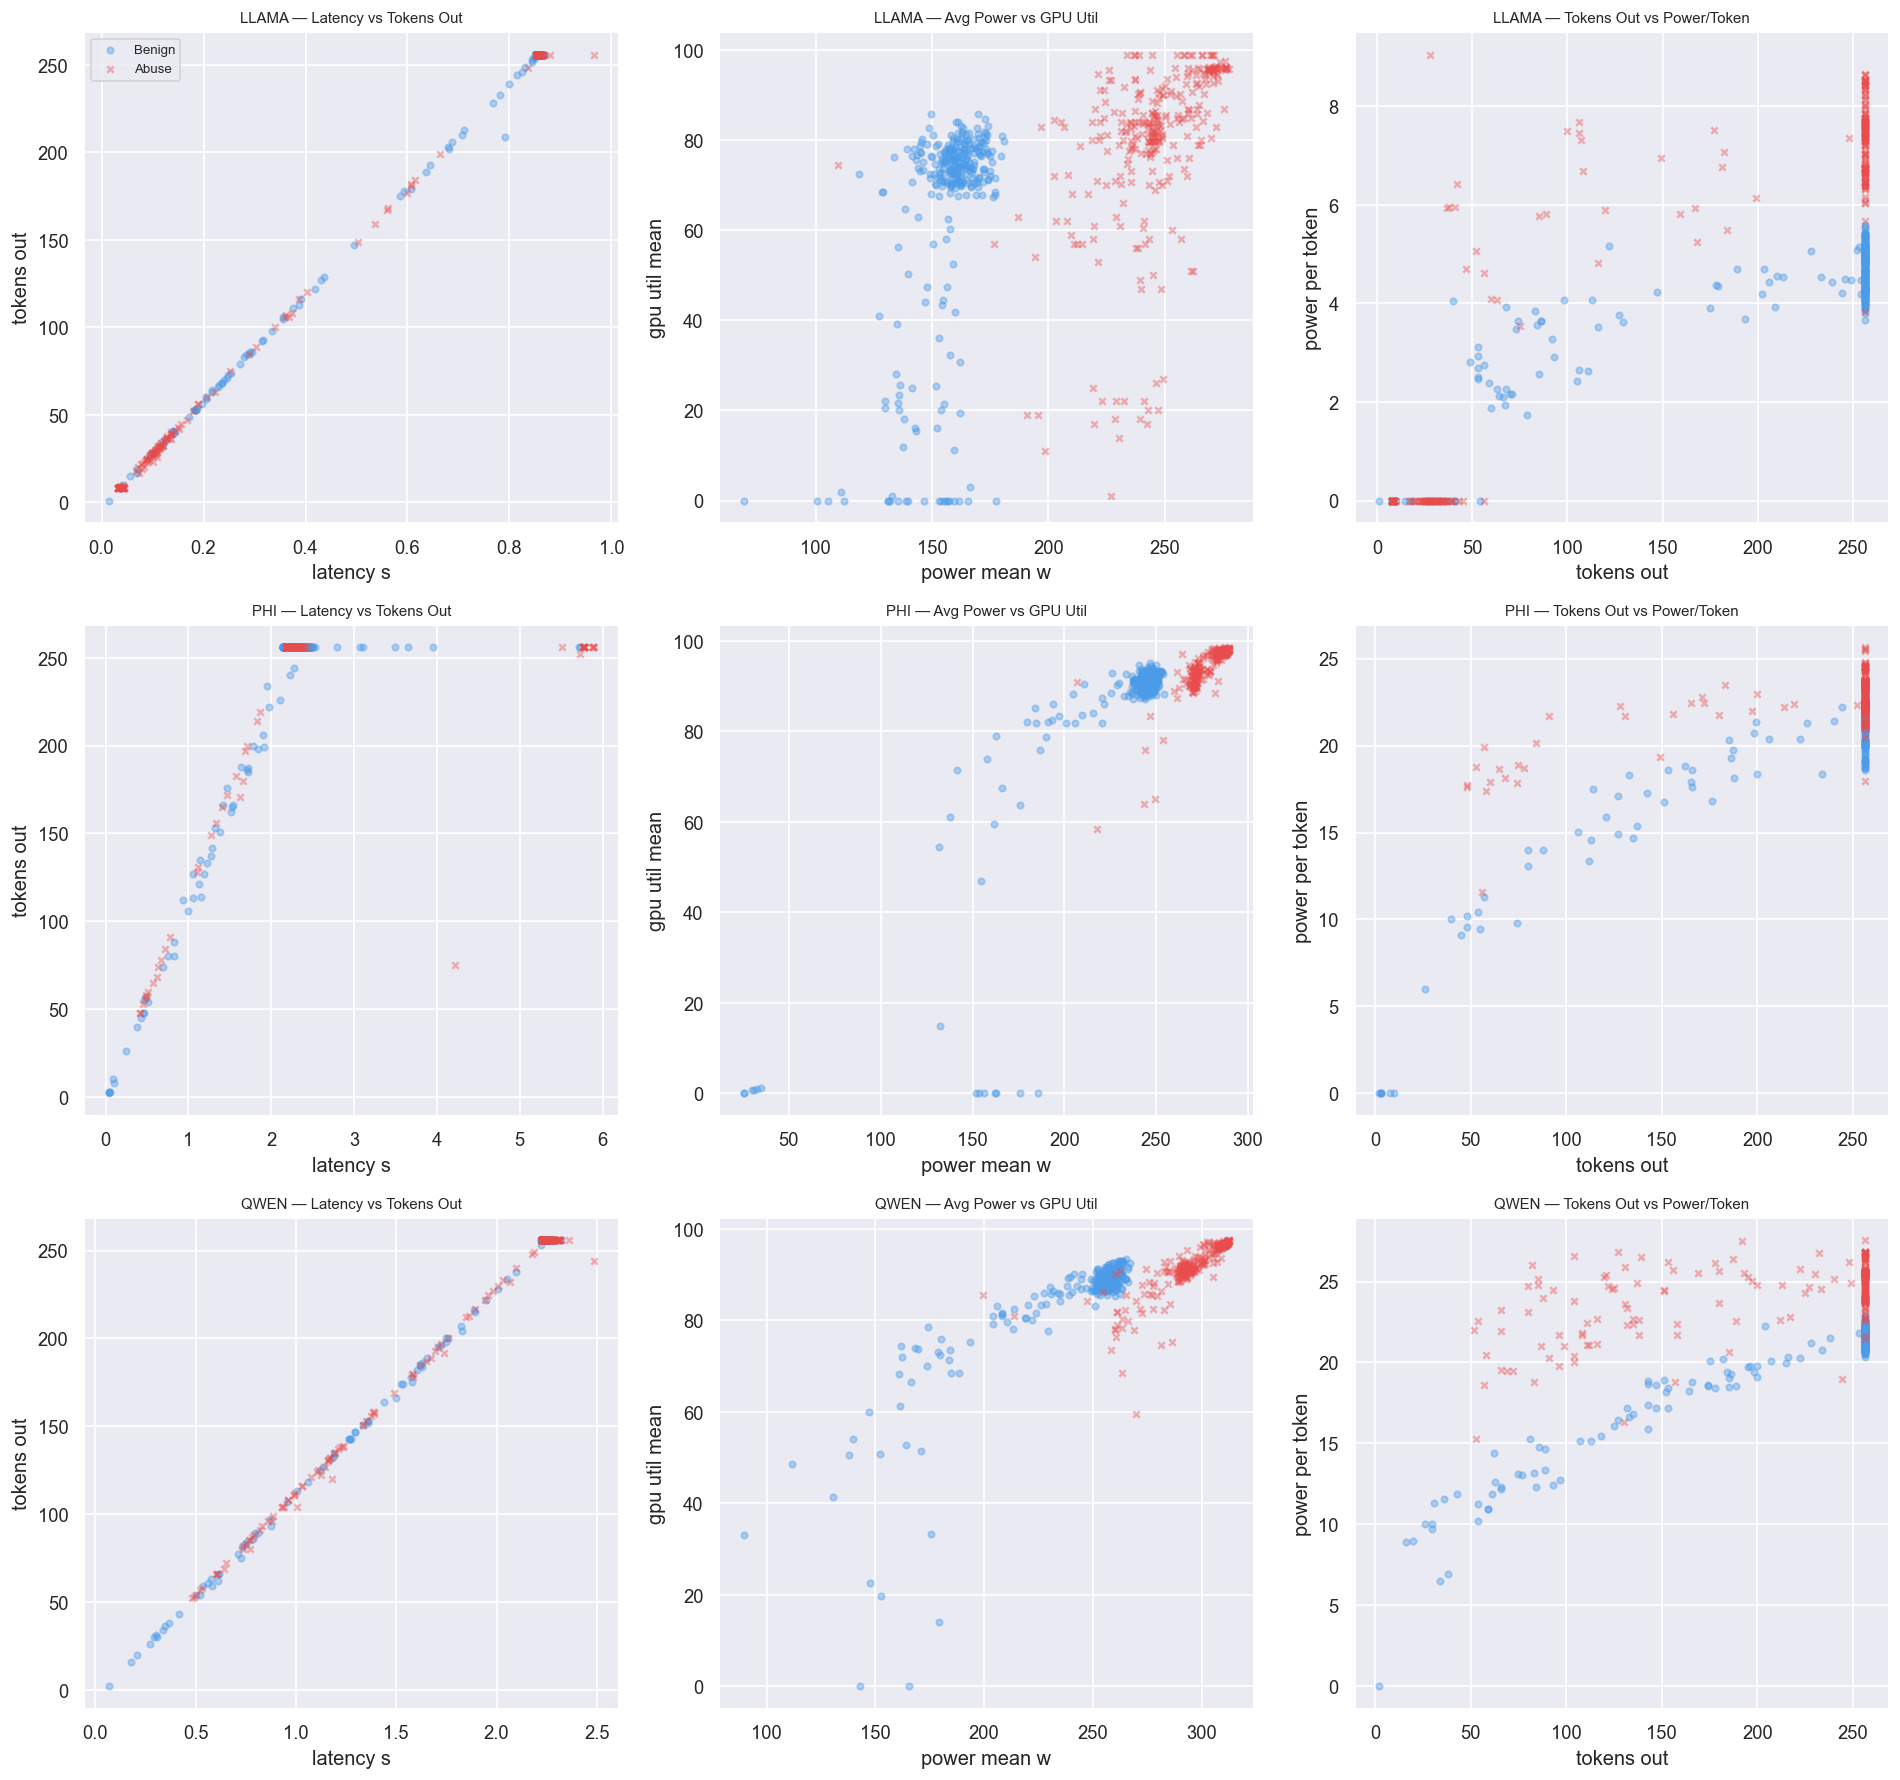

In [9]:
#Scatter plots of latency, power, and token throughput pairs per model
n_models = len(model_dfs)
fig, axes = plt.subplots(n_models, 3, figsize=(16, 5 * n_models))
if n_models == 1:
    axes = axes[np.newaxis, :]

plot_pairs = [
    ('latency_s', 'tokens_out', 'Latency vs Tokens Out'),
    ('power_mean_w', 'gpu_util_mean', 'Avg Power vs GPU Util'),
    ('tokens_out', 'power_per_token', 'Tokens Out vs Power/Token'),
]

for col_idx, (x_col, y_col, title) in enumerate(plot_pairs):
    if x_col not in df_all.columns or y_col not in df_all.columns:
        print(f'Skipping {title} — missing column(s): {x_col}, {y_col}')
        continue
    for row_idx, (model_name, df) in enumerate(model_dfs.items()):
        ax = axes[row_idx][col_idx]
        for label, color, marker in [(0, '#4c9be8', 'o'), (1, '#e84c4c', 'x')]:
            subset = df[df['label'] == label][[x_col, y_col]].dropna()
            if subset.empty:
                print(f'  WARNING: {model_name} label={label} has no valid rows for {x_col}/{y_col}')
                continue
            sample = subset.sample(min(300, len(subset)), random_state=42)
            ax.scatter(sample[x_col], sample[y_col],
                       c=color, alpha=0.4, s=15, marker=marker,
                       label='Benign' if label==0 else 'Abuse')
        ax.set_xlabel(x_col.replace('_', ' '))
        ax.set_ylabel(y_col.replace('_', ' '))
        ax.set_title(f'{model_name.upper()} — {title}', fontsize=9)
        if col_idx == 0 and row_idx == 0:
            ax.legend(fontsize=8)

plt.tight_layout()
display(fig)
plt.close(fig)

In [10]:
#Build mean feature summary table grouped by model and label
key_features = ['latency_s', 'tokens_out', 'power_mean_w', 'power_std_w',
                'power_per_token', 'gpu_util_mean', 'mem_used_mean_gb']
key_features = [c for c in key_features if c in df_all.columns]

summary_rows = []
for model_name, df in model_dfs.items():
    for label in [0, 1]:
        subset = df[df['label'] == label]
        row = {'Model': model_name.upper(), 'Label': 'Benign' if label==0 else 'Abuse', 'N': len(subset)}
        for feat in key_features:
            row[feat] = round(subset[feat].mean(), 3)
        summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows)
display(summary_df.set_index(['Model', 'Label']))

N  latency_s  tokens_out  power_mean_w  power_std_w  \
Model Label                                                           
LLAMA Benign  952      0.733     218.707       156.566       23.348   
      Abuse   337      0.546     162.249       245.543        3.274   
PHI   Benign  844      4.430     233.129       232.786       55.462   
      Abuse   400      2.340     243.532       279.679       10.718   
QWEN  Benign  998      1.967     224.274       243.395       60.115   
      Abuse   400      1.970     224.202       296.713       13.431   

              power_per_token  gpu_util_mean  mem_used_mean_gb  
Model Label                                                     
LLAMA Benign            4.178         65.310            14.991  
      Abuse             4.770         79.296            14.967  
PHI   Benign          644.367         85.749            15.787  
      Abuse            22.818         95.059            15.703  
QWEN  Benign           19.971         84.703            14.255  
      Abuse            24.469         92.394            14.148

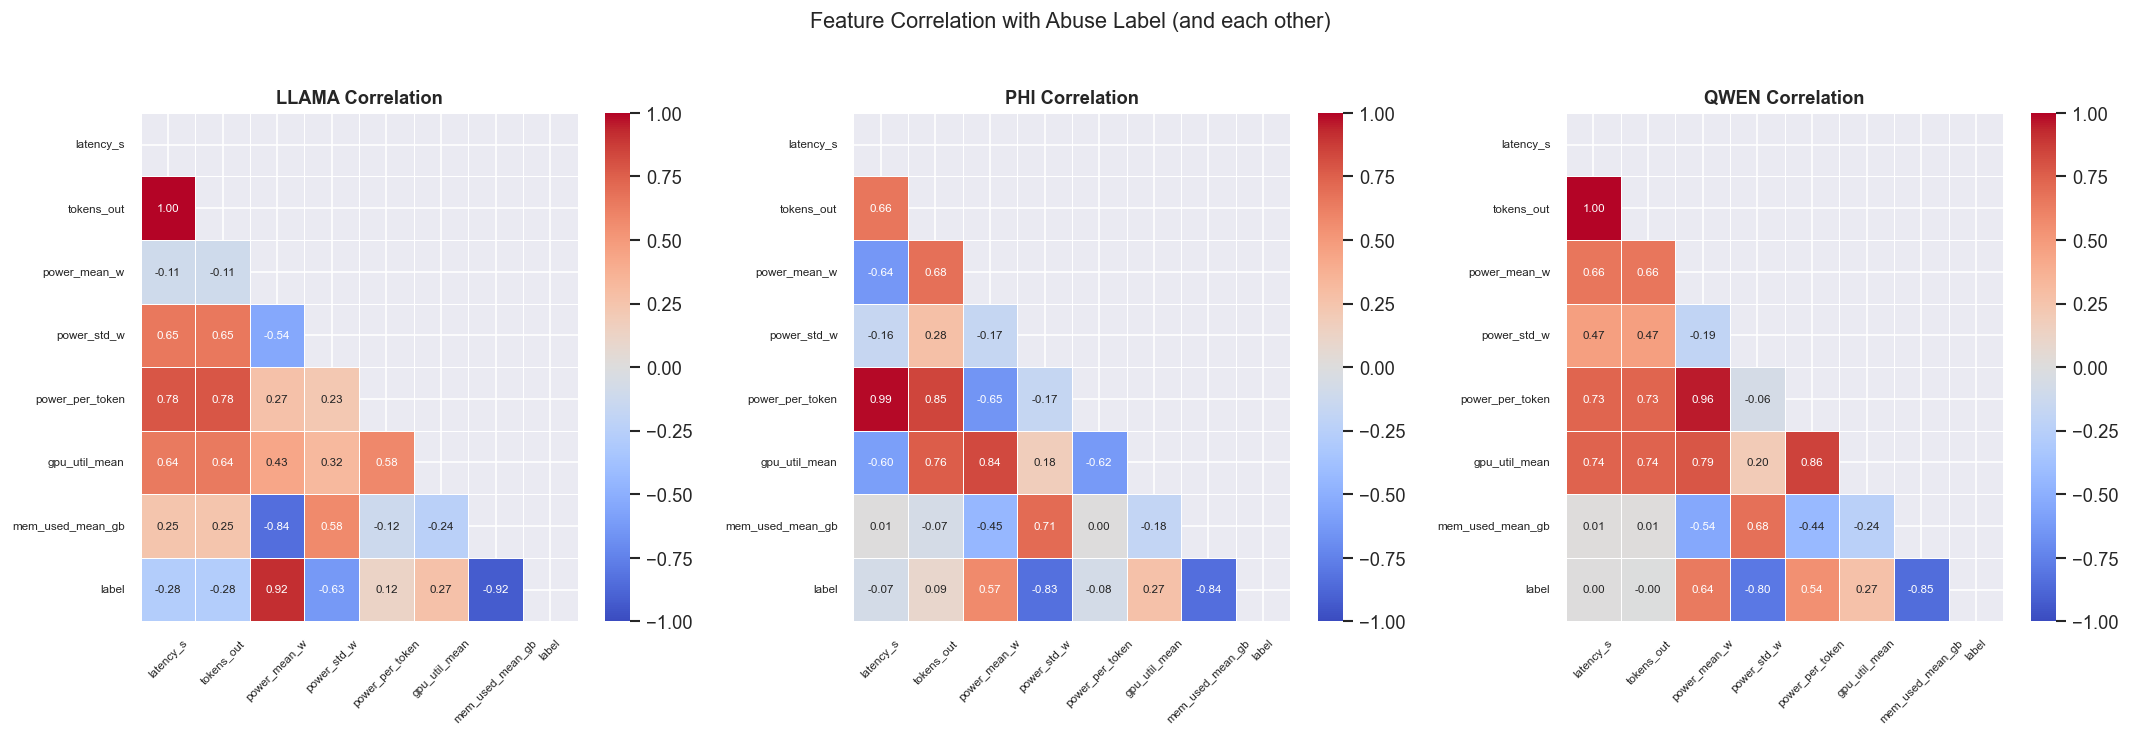

In [11]:
#Correlation heatmap of key features vs abuse label per model
corr_features = key_features + ['label']
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, (model_name, df) in zip(axes, model_dfs.items()):
    corr = df[[c for c in corr_features if c in df.columns]].corr()
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, ax=ax, mask=mask, annot=True, fmt='.2f',
                cmap='coolwarm', center=0, vmin=-1, vmax=1,
                annot_kws={'size': 7}, linewidths=0.5)
    ax.set_title(f'{model_name.upper()} Correlation', fontsize=11, fontweight='bold')
    ax.tick_params(axis='x', rotation=45, labelsize=7)
    ax.tick_params(axis='y', rotation=0, labelsize=7)

plt.suptitle('Feature Correlation with Abuse Label (and each other)', fontsize=13, y=1.02)
plt.tight_layout()
display(fig)
plt.close(fig)

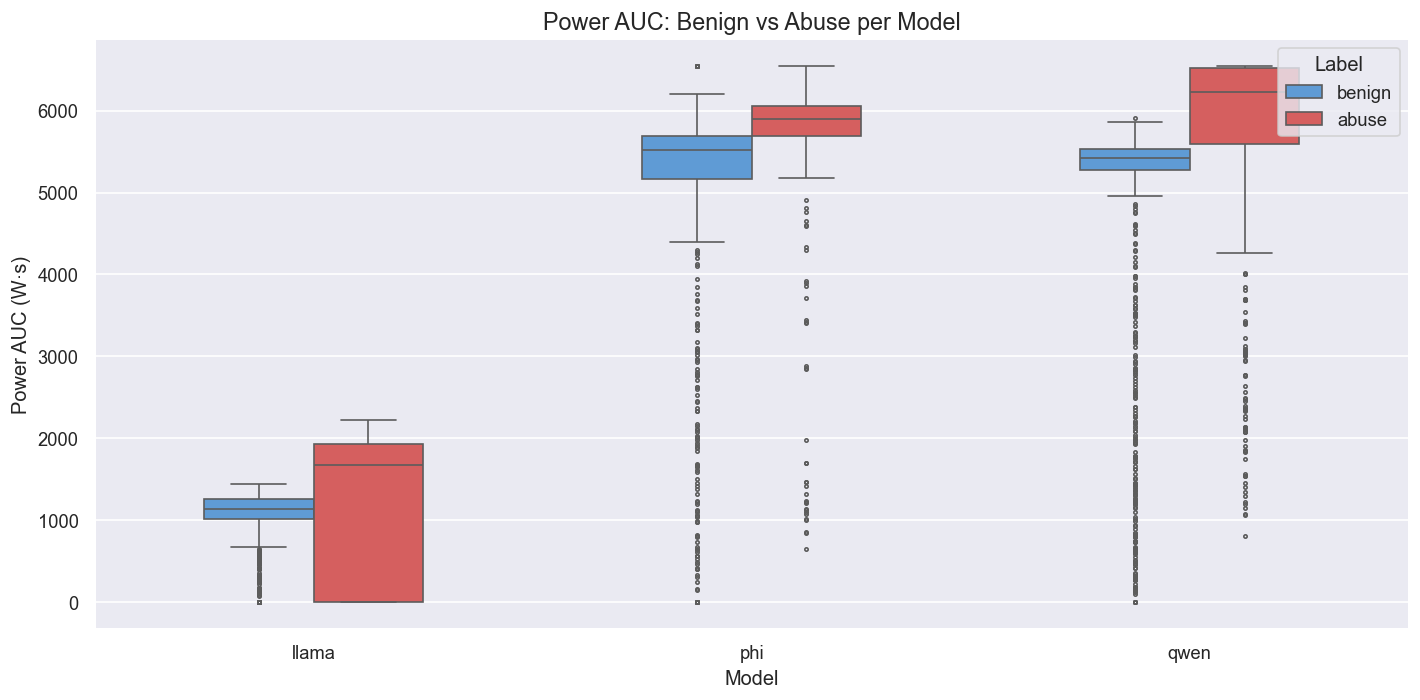

Saved: figures/fig_power_auc_box.pdf


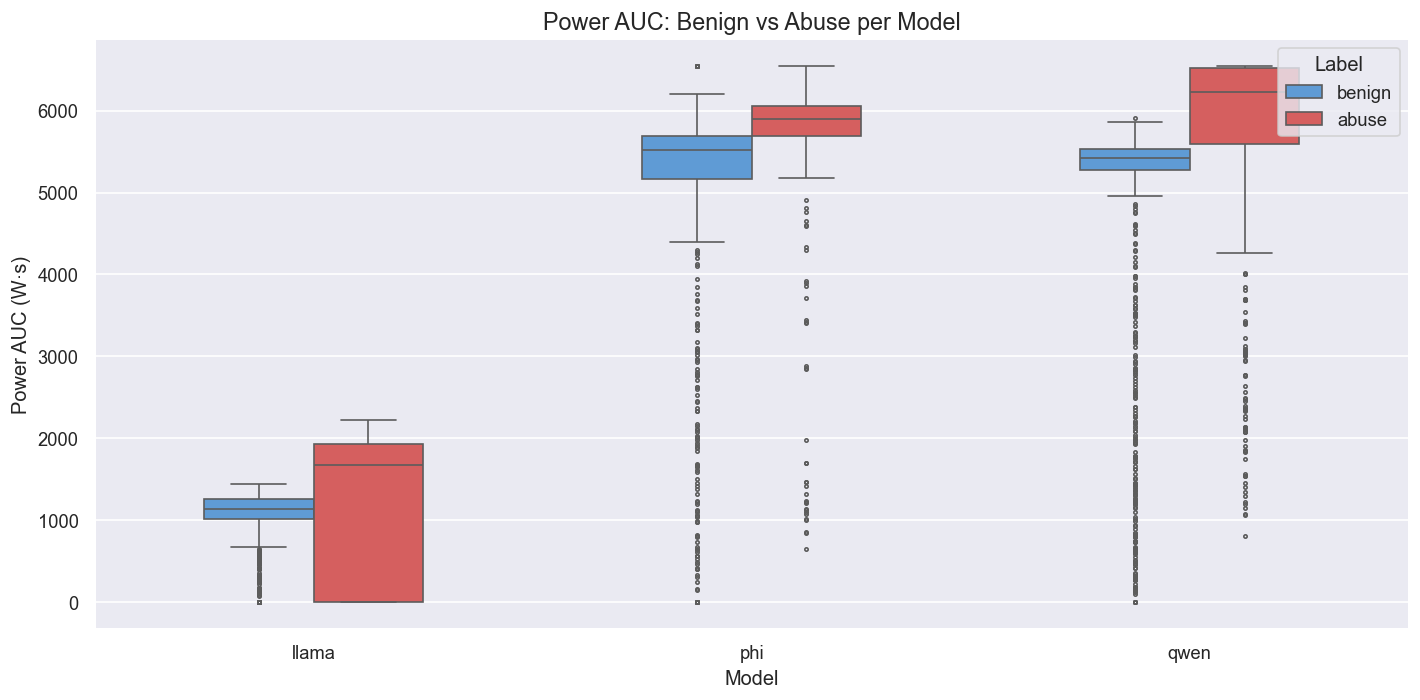

<Figure size 1440x720 with 0 Axes>

In [12]:
#Boxplot of power AUC by model and label, saved to figures
if 'power_auc' in df_all.columns:
    fig, ax = plt.subplots(figsize=(12, 6))

    df_plot = df_all.copy()
    cap = df_plot['power_auc'].quantile(0.98)
    df_plot['power_auc'] = df_plot['power_auc'].clip(upper=cap)

    sns.boxplot(
        data=df_plot,
        x='model_name', y='power_auc', hue='label_str',
        palette={'benign': '#4c9be8', 'abuse': '#e84c4c'},
        width=0.5, fliersize=2, ax=ax
    )
    ax.set_xlabel('Model', fontsize=12)
    ax.set_ylabel('Power AUC (W·s)', fontsize=12)
    ax.set_title('Power AUC: Benign vs Abuse per Model', fontsize=14)
    ax.legend(title='Label', loc='upper right')
    plt.tight_layout()
    plt.show()

os.makedirs('figures', exist_ok=True)
plt.savefig('figures/fig_power_auc_box.pdf', bbox_inches='tight', dpi=300)
plt.savefig('figures/fig_power_auc_box.png', bbox_inches='tight', dpi=300)
print("Saved: figures/fig_power_auc_box.pdf")

display(fig)
plt.close(fig)

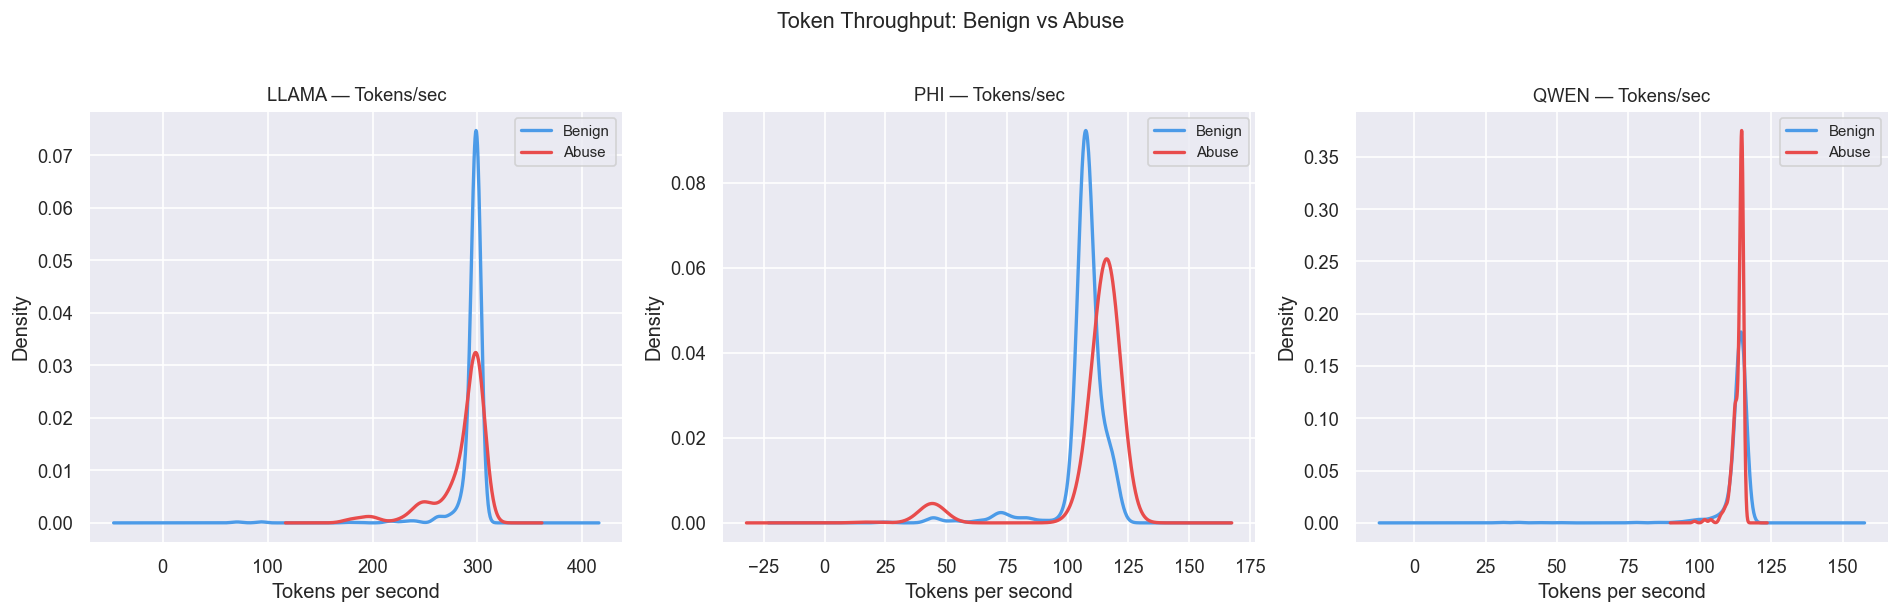


=== TOKENS/SEC SUMMARY (mean) ===
  LLAMA : benign=295.0 tok/s  |  abuse=284.9 tok/s  |  delta=-10.1
  PHI   : benign=106.9 tok/s  |  abuse=110.9 tok/s  |  delta=+4.0
  QWEN  : benign=112.8 tok/s  |  abuse=113.5 tok/s  |  delta=+0.7


In [13]:
#KDE of tokens/sec throughput by model and label, with mean summary
df_all['tokens_per_sec'] = df_all['tokens_out'] / df_all['latency_s'].replace(0, np.nan)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (model_name, df) in zip(axes, model_dfs.items()):
    df = df.copy()
    df['tokens_per_sec'] = df['tokens_out'] / df['latency_s'].replace(0, np.nan)
    for label, color in [(0, '#4c9be8'), (1, '#e84c4c')]:
        vals = df[df['label']==label]['tokens_per_sec'].dropna()
        vals = vals[vals < vals.quantile(0.99)]
        vals.plot.kde(ax=ax, label='Benign' if label==0 else 'Abuse',
                     color=color, linewidth=2)
    ax.set_title(f'{model_name.upper()} — Tokens/sec', fontsize=11)
    ax.set_xlabel('Tokens per second')
    ax.legend(fontsize=9)

plt.suptitle('Token Throughput: Benign vs Abuse', fontsize=13, y=1.02)
plt.tight_layout()
display(fig)
plt.close(fig)

print('\n=== TOKENS/SEC SUMMARY (mean) ===')
for model_name, df in model_dfs.items():
    df = df.copy()
    df['tps'] = df['tokens_out'] / df['latency_s'].replace(0, np.nan)
    b = df[df['label']==0]['tps'].mean()
    a = df[df['label']==1]['tps'].mean()
    print(f'  {model_name.upper():6s}: benign={b:.1f} tok/s  |  abuse={a:.1f} tok/s  |  delta={a-b:+.1f}')


Top 10 features correlated with abuse label (across all models combined):
power_min_w      0.9125
power_std_w      0.6443
gpu_util_std     0.6135
power_mean_w     0.5597
gpu_util_mean    0.2548
power_max_w      0.2192
tokens_in        0.1447
power_auc        0.0892
tokens_out       0.0778
gpu_util_max     0.0433
Name: label, dtype: float64
Saved: figures/fig_feature_corr.pdf


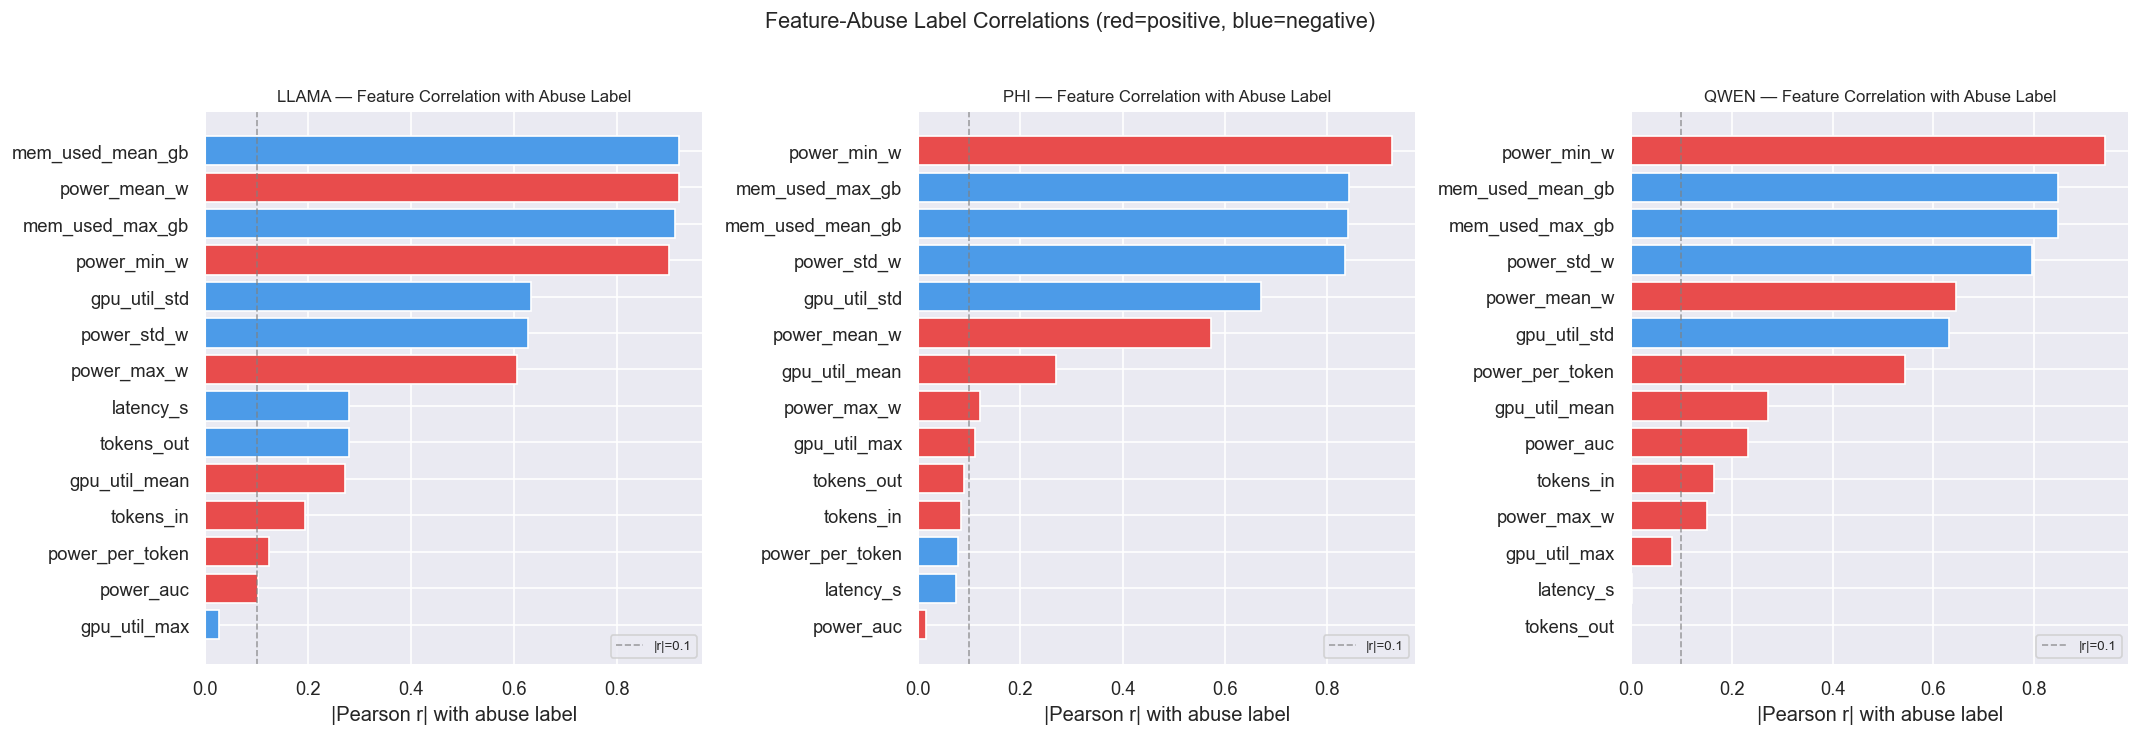

In [14]:
#Bar chart of absolute Pearson correlation of each feature with the abuse label
feature_cols = [c for c in numeric_cols if c not in ['label', 'n_samples'] and c in df_all.columns]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, (model_name, df) in zip(axes, model_dfs.items()):
    corrs = df[[c for c in feature_cols if c in df.columns] + ['label']].corr()['label'].drop('label')
    corrs_sorted = corrs.abs().sort_values(ascending=True)
    colors = ['#e84c4c' if corrs[i] > 0 else '#4c9be8' for i in corrs_sorted.index]
    ax.barh(corrs_sorted.index, corrs_sorted.values, color=colors)
    ax.axvline(0.1, color='gray', linestyle='--', linewidth=1, alpha=0.7, label='|r|=0.1')
    ax.set_xlabel('|Pearson r| with abuse label')
    ax.set_title(f'{model_name.upper()} — Feature Correlation with Abuse Label', fontsize=10)
    ax.legend(fontsize=8)

plt.suptitle('Feature-Abuse Label Correlations (red=positive, blue=negative)', fontsize=13, y=1.02)
plt.tight_layout()

print('\nTop 10 features correlated with abuse label (across all models combined):')
all_corrs = df_all[[c for c in feature_cols if c in df_all.columns] + ['label']].corr()['label'].drop('label')
print(all_corrs.abs().sort_values(ascending=False).head(10).round(4))

os.makedirs('figures', exist_ok=True)
plt.savefig('figures/fig_feature_corr.pdf', bbox_inches='tight', dpi=300)
plt.savefig('figures/fig_feature_corr.png', bbox_inches='tight', dpi=300)
print("Saved: figures/fig_feature_corr.pdf")

display(fig)
plt.close(fig)

In [15]:
#Add derived features and export master DataFrame to CSV
df_all['tokens_per_sec'] = df_all['tokens_out'] / df_all['latency_s'].replace(0, np.nan)
df_all['power_range_w']  = df_all['power_max_w'] - df_all['power_min_w']

output_path = 'final_data/master_combined.csv'
df_all.to_csv(output_path, index=False)

print(f'Exported {len(df_all):,} rows → {output_path}')
print(f'Columns: {list(df_all.columns)}')
print(f'\nFinal abuse label balance:')
print(df_all.groupby(['model_name','label_str']).size().unstack())

Exported 3,931 rows → final_data/master_combined.csv
Columns: ['label', 'request_id', 'model', 't_start', 't_end', 'latency_s', 'tokens_out', 'tokens_in', 'prompt_hash', 'prompt_preview', 'endpoint', 'status_code', 'power_mean_w', 'power_max_w', 'power_min_w', 'power_std_w', 'power_auc', 'power_per_token', 'gpu_util_mean', 'gpu_util_max', 'gpu_util_std', 'mem_used_mean_gb', 'mem_used_max_gb', 'n_samples', 'model_name', 'label_str', 'tokens_per_sec', 'power_range_w']

Final abuse label balance:
label_str   abuse  benign
model_name               
llama         337     952
phi           400     844
qwen          400     998


In [16]:
#Diagnose proxy label leakage, token ceiling, dataset size, and single-feature separability
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_auc_score
import math

print('=' * 65)
print('DIAG 1 — Proxy label leakage (tokens_out, n_samples, latency_s)')
print('=' * 65)
proxy_cols = [c for c in ['tokens_out','n_samples','latency_s','tokens_in'] if c in df_all.columns]
for col in proxy_cols:
    g0 = df_all[df_all['label']==0][col].dropna()
    g1 = df_all[df_all['label']==1][col].dropna()
    overlap = g0.between(g1.min(), g1.max()).mean()
    stat, p = stats.mannwhitneyu(g0, g1, alternative='two-sided')
    print(f'  {col:<20} | benign μ={g0.mean():7.2f}  abuse μ={g1.mean():7.2f}  overlap={overlap:.1%}  p={p:.2e}')
    if g0.max() == g1.max() and g0.min() < g1.min():
        print(f'    ⚠ shared max — possible max_tokens ceiling on abuse data')

print()
print('=' * 65)
print('DIAG 2 — tokens_out ceiling check (max_tokens cap effect)')
print('=' * 65)
if 'tokens_out' in df_all.columns:
    for label, name in [(0,'benign'),(1,'abuse')]:
        t = df_all[df_all['label']==label]['tokens_out']
        max_val = t.max()
        pct_at_max = (t == max_val).mean()
        print(f'  {name:8s} | max={max_val}  std={t.std():.2f}  pct_at_max={pct_at_max:.1%}')
    if df_all[df_all['label']==1]['tokens_out'].std() < 5:
        print('  ⚠ Abuse tokens_out near-zero std — all abuse responses hit same token cap.')
        print('    This is a PROXY LABEL. Exclude tokens_out from FEATURE_COLS in Cell 13.')

print()
print('=' * 65)
print('DIAG 3 — Dataset and test set size')
print('=' * 65)
total_rows  = len(df_all)
abuse_rows  = (df_all['label']==1).sum()
benign_rows = (df_all['label']==0).sum()
test_abuse  = int(abuse_rows * 0.2)
test_benign = int(benign_rows * 0.2)
print(f'  Total rows    : {total_rows:,}')
print(f'  Benign rows   : {benign_rows:,}')
print(f'  Abuse rows    : {abuse_rows:,}')
print(f'  Est test set  : ~{test_abuse+test_benign:,} rows  ({test_benign} benign / {test_abuse} abuse)')
if test_abuse > 0:
    ci = 2 * 1.96 * math.sqrt(0.99 * 0.01 / test_abuse)
    print(f'  95% CI on recall (p=0.99, n={test_abuse}): ±{ci:.4f}')
    if test_abuse < 500:
        print(f'  ⚠ Only {test_abuse} abuse test samples — metric confidence is low.')
        print(f'    Need ~500+ abuse test samples for 95% CI width < 0.04.')

print()
print('=' * 65)
print('DIAG 4 — Single-feature separability (depth-1 decision stump AUC)')
print('=' * 65)
diag_cols = [c for c in ['tokens_out','n_samples','latency_s','power_mean_w',
                          'power_per_token','power_auc','gpu_util_mean'] if c in df_all.columns]
diag_df = df_all[diag_cols + ['label']].dropna()
print(f'  {"Feature":<22} {"Stump AUC":>10}  Verdict')
print(f'  {"-"*22} {"-"*10}  {"-"*35}')
for col in diag_cols:
    dt = DecisionTreeClassifier(max_depth=1, random_state=42)
    dt.fit(diag_df[[col]], diag_df['label'])
    auc = roc_auc_score(diag_df['label'], dt.predict_proba(diag_df[[col]])[:,1])
    verdict = '⚠ PROXY LABEL — remove from features' if auc > 0.90 else \
              ('⚠ strong — verify not proxy' if auc > 0.75 else 'OK')
    print(f'  {col:<22} {auc:>10.4f}  {verdict}')

print()
print('=' * 65)
print('DIAG 5 — Recommended next steps')
print('=' * 65)
print("""
  If DIAG 4 shows tokens_out / n_samples stump AUC > 0.90:
    → Remove from FEATURE_COLS in Cell 13 and retrain.
    → These encode generation script parameters, not abuse signal.

  If scores stay >0.99 after removing proxy features:
    → Power/GPU signal is genuinely strong (this is publishable).
    → Validate with cross-model holdout: train on llama+phi, test on qwen only.
    → Run temporal split: Cell 14 USE_TEMPORAL_SPLIT=True.

  If scores drop to 0.65-0.85 after removing proxies:
    → Original scores were inflated. Honest result needs:
       (a) variable max_tokens in abuse data collection
       (b) more diverse attack types beyond JailbreakBench clean prompts
       (c) larger dataset (target 2000+ abuse samples per model)
""")

DIAG 1 — Proxy label leakage (tokens_out, n_samples, latency_s)
  tokens_out           | benign μ= 225.01  abuse μ= 212.64  overlap=99.1%  p=8.02e-04
    ⚠ shared max — possible max_tokens ceiling on abuse data
  n_samples            | benign μ=  22.58  abuse μ=  15.91  overlap=98.0%  p=5.10e-05
  latency_s            | benign μ=   2.29  abuse μ=   1.68  overlap=99.2%  p=2.36e-08
  tokens_in            | benign μ=  84.87  abuse μ= 128.63  overlap=93.1%  p=1.00e-19

DIAG 2 — tokens_out ceiling check (max_tokens cap effect)
  benign   | max=256.0  std=67.53  pct_at_max=77.5%
  abuse    | max=256.0  std=81.61  pct_at_max=74.2%

DIAG 3 — Dataset and test set size
  Total rows    : 3,931
  Benign rows   : 2,794
  Abuse rows    : 1,137
  Est test set  : ~785 rows  (558 benign / 227 abuse)
  95% CI on recall (p=0.99, n=227): ±0.0259
  ⚠ Only 227 abuse test samples — metric confidence is low.
    Need ~500+ abuse test samples for 95% CI width < 0.04.

DIAG 4 — Single-feature separability (dept

In [17]:
#Define three feature set variants for ablation and select active set for ML training
FEATURE_SETS = {
    'telemetry_only': [
        'power_mean_w', 'power_max_w', 'power_min_w', 'power_std_w',
        'power_auc', 'power_per_token', 'power_range_w',
        'gpu_util_mean', 'gpu_util_max', 'gpu_util_std',
        'mem_used_mean_gb', 'model_enc'
    ],
    'telemetry_plus_timing': [
        'power_mean_w', 'power_max_w', 'power_min_w', 'power_std_w',
        'power_auc', 'power_per_token', 'power_range_w',
        'gpu_util_mean', 'gpu_util_max', 'gpu_util_std',
        'mem_used_mean_gb', 'tokens_per_sec',
        'latency_s', 'tokens_out', 'model_enc'
    ],
    'all_features': [
        'latency_s', 'tokens_out', 'tokens_in',
        'power_mean_w', 'power_max_w', 'power_min_w', 'power_std_w',
        'power_auc', 'power_per_token', 'power_range_w',
        'gpu_util_mean', 'gpu_util_max', 'gpu_util_std',
        'mem_used_mean_gb', 'tokens_per_sec', 'model_enc'
    ],
    'time_only': ['latency_s', 'tokens_out', 'tokens_in']
}

ACTIVE_FEATURE_SET = 'telemetry_only'

FEATURE_COLS = [c for c in FEATURE_SETS[ACTIVE_FEATURE_SET] if c in df_all.columns]
TARGET = 'label'

df_ml = df_all[FEATURE_COLS + [TARGET]].dropna().copy()
X = df_ml[FEATURE_COLS].values
y = df_ml[TARGET].values

print(f'Active feature set : {ACTIVE_FEATURE_SET}')
print(f'ML dataset         : {X.shape[0]:,} samples · {X.shape[1]} features')
print(f'Class balance      : benign={(y==0).sum():,}  abuse={(y==1).sum():,}')
print(f'Imbalance ratio    : {(y==0).sum()/(y==1).sum():.2f}:1')
print(f'Features           : {FEATURE_COLS}')
print()
print('To run full ablation, change ACTIVE_FEATURE_SET and re-run cells 13-24:')
for k, v in FEATURE_SETS.items():
    available = [c for c in v if c in df_all.columns]
    print(f'  "{k}" -> {len(available)} features')

Active feature set : telemetry_only
ML dataset         : 3,931 samples · 11 features
Class balance      : benign=2,794  abuse=1,137
Imbalance ratio    : 2.46:1
Features           : ['power_mean_w', 'power_max_w', 'power_min_w', 'power_std_w', 'power_auc', 'power_per_token', 'power_range_w', 'gpu_util_mean', 'gpu_util_max', 'gpu_util_std', 'mem_used_mean_gb']

To run full ablation, change ACTIVE_FEATURE_SET and re-run cells 13-24:
  "telemetry_only" -> 11 features
  "telemetry_plus_timing" -> 14 features
  "all_features" -> 15 features
  "time_only" -> 3 features


In [18]:
#Verify label ordering, audit NaNs by label, check temporal split option, scale features
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold

print('=== STEP 1: Pre-split label block check ===')
block_runs = (df_ml[TARGET] != df_ml[TARGET].shift()).sum()
print(f'  Label change transitions in df_ml: {block_runs}')
print(f'  (2 = clean two-block sort | high = already shuffled)')
print(f'  First 5 labels : {list(df_ml[TARGET].values[:5])}')
print(f'  Last  5 labels : {list(df_ml[TARGET].values[-5:])}')

print('\n=== STEP 2: NaN audit by label (before drop) ===')
pre_drop = df_all[FEATURE_COLS + [TARGET]].copy()
for col in FEATURE_COLS:
    null_by_label = pre_drop.groupby(TARGET)[col].apply(lambda s: s.isnull().sum())
    if null_by_label.sum() > 0:
        print(f'  {col:<22} nulls → label=0: {null_by_label.get(0,0)}  label=1: {null_by_label.get(1,0)}')
rows_before = len(pre_drop)
rows_after  = len(df_ml)
dropped = rows_before - rows_after
print(f'  Rows dropped by dropna: {dropped:,} of {rows_before:,} ({100*dropped/rows_before:.1f}%)')
if dropped > 0:
    print(f'  Post-drop label balance: {pd.Series(y).value_counts().to_dict()}')

print('\n=== STEP 3: Temporal ordering check ===')
USE_TEMPORAL_SPLIT = False
TEMPORAL_COL = 't_start'

if TEMPORAL_COL in df_ml.columns:
    t_sorted = df_ml[TEMPORAL_COL].sort_values()
    cutoff_idx = int(len(t_sorted) * 0.8)
    cutoff_time = t_sorted.iloc[cutoff_idx]
    print(f'  t_start range: {df_ml[TEMPORAL_COL].min():.0f} → {df_ml[TEMPORAL_COL].max():.0f}')
    print(f'  Temporal 80/20 cutoff: {cutoff_time:.0f}')
    temporal_train_abuse = df_ml[df_ml[TEMPORAL_COL] <  cutoff_time][TARGET].mean()
    temporal_test_abuse  = df_ml[df_ml[TEMPORAL_COL] >= cutoff_time][TARGET].mean()
    print(f'  Abuse rate — temporal train: {temporal_train_abuse:.3f}  test: {temporal_test_abuse:.3f}')
    if abs(temporal_train_abuse - temporal_test_abuse) > 0.1:
        print('  ⚠ Abuse rate differs >10% across time — label collection was not uniform.')
        print('    Temporal split will be harder; random split metrics will be optimistic.')
    print(f'\n  USE_TEMPORAL_SPLIT = {USE_TEMPORAL_SPLIT}')
    print('  Set USE_TEMPORAL_SPLIT = True above to use time-based train/test split.')
else:
    print(f'  {TEMPORAL_COL} not in df_ml — temporal split unavailable. Using random split.')
    USE_TEMPORAL_SPLIT = False

print('\n=== STEP 4: Split ===')
if USE_TEMPORAL_SPLIT and TEMPORAL_COL in df_ml.columns:
    train_mask = df_ml[TEMPORAL_COL] < cutoff_time
    X_train = df_ml.loc[train_mask,  FEATURE_COLS].values
    X_test  = df_ml.loc[~train_mask, FEATURE_COLS].values
    y_train = df_ml.loc[train_mask,  TARGET].values
    y_test  = df_ml.loc[~train_mask, TARGET].values
    print('  Using TEMPORAL split (train=past, test=future)')
else:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, shuffle=True, stratify=y
    )
    print('  Using RANDOM stratified split')

print(f'  Train: {len(y_train):,}  |  Test: {len(y_test):,}')
print(f'  Train abuse rate: {y_train.mean():.4f}  |  Test abuse rate: {y_test.mean():.4f}')

train_transitions = (pd.Series(y_train) != pd.Series(y_train).shift()).sum()
print(f'  Label transitions in y_train: {train_transitions} (should be >> 2 if shuffled correctly)')

print('\n=== STEP 5: Scaler fit (train only) ===')
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)
print(f'  Scaler fitted on {len(X_train):,} train rows only ✓')
print(f'  Feature means (train): {np.round(scaler.mean_[:4], 3)} ...')

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

neg_pos_ratio = (y_train == 0).sum() / (y_train == 1).sum()
print(f'\n  Imbalance ratio (neg/pos) in train: {neg_pos_ratio:.2f}:1')

results_summary = {}
print('\nCell 14 complete ✓')

=== STEP 1: Pre-split label block check ===
  Label change transitions in df_ml: 6
  (2 = clean two-block sort | high = already shuffled)
  First 5 labels : [np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0)]
  Last  5 labels : [np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1)]

=== STEP 2: NaN audit by label (before drop) ===
  Rows dropped by dropna: 0 of 3,931 (0.0%)

=== STEP 3: Temporal ordering check ===
  t_start not in df_ml — temporal split unavailable. Using random split.

=== STEP 4: Split ===
  Using RANDOM stratified split
  Train: 3,144  |  Test: 787
  Train abuse rate: 0.2891  |  Test abuse rate: 0.2897
  Label transitions in y_train: 1298 (should be >> 2 if shuffled correctly)

=== STEP 5: Scaler fit (train only) ===
  Scaler fitted on 3,144 train rows only ✓
  Feature means (train): [228.995 266.884 175.346  35.407] ...

  Imbalance ratio (neg/pos) in train: 2.46:1

Cell 14 complete ✓


In [19]:
#Train Random Forest with 5-fold CV and evaluate on held-out test set
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_validate
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.metrics import f1_score

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=5,
    class_weight='balanced',
    n_jobs=-1,
    random_state=42
)

cv_rf = cross_validate(rf, X_train, y_train, cv=cv,
                       scoring=['roc_auc', 'f1', 'precision', 'recall'],
                       return_train_score=False)

print('=== RANDOM FOREST — 5-fold CV ===')
for metric in ['roc_auc', 'f1', 'precision', 'recall']:
    vals = cv_rf[f'test_{metric}']
    print(f'  {metric:<12}: {vals.mean():.4f} ± {vals.std():.4f}')

rf.fit(X_train, y_train)
y_pred_rf  = rf.predict(X_test)
y_prob_rf  = rf.predict_proba(X_test)[:, 1]

print('\n=== RANDOM FOREST — Hold-out Test ===')
print(classification_report(y_test, y_pred_rf, target_names=['Benign', 'Abuse']))
auc_rf = roc_auc_score(y_test, y_prob_rf)
print(f'ROC-AUC: {auc_rf:.4f}')

results_summary['Random Forest'] = {
    'roc_auc': auc_rf,
    'f1': f1_score(y_test, y_pred_rf),
    'y_prob': y_prob_rf
}

=== RANDOM FOREST — 5-fold CV ===
  roc_auc     : 0.9999 ± 0.0001
  f1          : 0.9950 ± 0.0027
  precision   : 0.9989 ± 0.0022
  recall      : 0.9912 ± 0.0044

=== RANDOM FOREST — Hold-out Test ===
              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00       559
       Abuse       1.00      0.99      1.00       228

    accuracy                           1.00       787
   macro avg       1.00      1.00      1.00       787
weighted avg       1.00      1.00      1.00       787

ROC-AUC: 0.9998


In [20]:
#Train XGBoost with class imbalance weighting, 5-fold CV, and held-out evaluation
import xgboost as xgb

neg_pos_ratio = (y_train == 0).sum() / (y_train == 1).sum()

xgb_clf = xgb.XGBClassifier(
    n_estimators=400,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=neg_pos_ratio,
    use_label_encoder=False,
    eval_metric='logloss',
    n_jobs=-1,
    random_state=42,
    verbosity=0
)

cv_xgb = cross_validate(xgb_clf, X_train, y_train, cv=cv,
                        scoring=['roc_auc', 'f1', 'precision', 'recall'],
                        return_train_score=False)

print('=== XGBOOST — 5-fold CV ===')
for metric in ['roc_auc', 'f1', 'precision', 'recall']:
    vals = cv_xgb[f'test_{metric}']
    print(f'  {metric:<12}: {vals.mean():.4f} ± {vals.std():.4f}')

xgb_clf.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

y_pred_xgb = xgb_clf.predict(X_test)
y_prob_xgb = xgb_clf.predict_proba(X_test)[:, 1]

print('\n=== XGBOOST — Hold-out Test ===')
print(classification_report(y_test, y_pred_xgb, target_names=['Benign', 'Abuse']))
auc_xgb = roc_auc_score(y_test, y_prob_xgb)
print(f'ROC-AUC: {auc_xgb:.4f}')

results_summary['XGBoost'] = {
    'roc_auc': auc_xgb,
    'f1': f1_score(y_test, y_pred_xgb),
    'y_prob': y_prob_xgb
}

=== XGBOOST — 5-fold CV ===
  roc_auc     : 0.9999 ± 0.0001
  f1          : 0.9967 ± 0.0027
  precision   : 0.9978 ± 0.0027
  recall      : 0.9956 ± 0.0041

=== XGBOOST — Hold-out Test ===
              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00       559
       Abuse       1.00      0.99      1.00       228

    accuracy                           1.00       787
   macro avg       1.00      1.00      1.00       787
weighted avg       1.00      1.00      1.00       787

ROC-AUC: 0.9994


In [21]:
#Train LightGBM with early stopping, 5-fold CV, and held-out evaluation
import lightgbm as lgb

lgb_clf = lgb.LGBMClassifier(
    n_estimators=400,
    max_depth=7,
    learning_rate=0.05,
    num_leaves=63,
    subsample=0.8,
    colsample_bytree=0.8,
    class_weight='balanced',
    n_jobs=-1,
    random_state=42,
    verbose=-1
)

cv_lgb = cross_validate(lgb_clf, X_train, y_train, cv=cv,
                        scoring=['roc_auc', 'f1', 'precision', 'recall'],
                        return_train_score=False)

print('=== LIGHTGBM — 5-fold CV ===')
for metric in ['roc_auc', 'f1', 'precision', 'recall']:
    vals = cv_lgb[f'test_{metric}']
    print(f'  {metric:<12}: {vals.mean():.4f} ± {vals.std():.4f}')

lgb_clf.fit(X_train, y_train,
            eval_set=[(X_test, y_test)],
            callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)])

y_pred_lgb = lgb_clf.predict(X_test)
y_prob_lgb = lgb_clf.predict_proba(X_test)[:, 1]

print('\n=== LIGHTGBM — Hold-out Test ===')
print(classification_report(y_test, y_pred_lgb, target_names=['Benign', 'Abuse']))
auc_lgb = roc_auc_score(y_test, y_prob_lgb)
print(f'ROC-AUC: {auc_lgb:.4f}')

results_summary['LightGBM'] = {
    'roc_auc': auc_lgb,
    'f1': f1_score(y_test, y_pred_lgb),
    'y_prob': y_prob_lgb
}

=== LIGHTGBM — 5-fold CV ===
  roc_auc     : 1.0000 ± 0.0000
  f1          : 0.9972 ± 0.0017
  precision   : 1.0000 ± 0.0000
  recall      : 0.9945 ± 0.0035

=== LIGHTGBM — Hold-out Test ===
              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00       559
       Abuse       1.00      0.99      1.00       228

    accuracy                           1.00       787
   macro avg       1.00      1.00      1.00       787
weighted avg       1.00      1.00      1.00       787

ROC-AUC: 0.9992


In [22]:
#Define and train a 3-layer MLP with BatchNorm and weighted BCE loss for abuse detection
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

class AbuseDetectorMLP(nn.Module):
    #3-layer MLP with BatchNorm and Dropout for binary abuse classification
    def __init__(self, input_dim, hidden_dims=(128, 64, 32), dropout=0.3):
        super().__init__()
        layers = []
        prev = input_dim
        for h in hidden_dims:
            layers += [
                nn.Linear(prev, h),
                nn.BatchNorm1d(h),
                nn.ReLU(),
                nn.Dropout(dropout)
            ]
            prev = h
        layers.append(nn.Linear(prev, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x).squeeze(1)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Training on: {device}')

X_tr_t = torch.tensor(X_train_sc, dtype=torch.float32)
y_tr_t = torch.tensor(y_train,    dtype=torch.float32)
X_te_t = torch.tensor(X_test_sc,  dtype=torch.float32)
y_te_t = torch.tensor(y_test,     dtype=torch.float32)

train_ds = TensorDataset(X_tr_t, y_tr_t)
train_dl = DataLoader(train_ds, batch_size=256, shuffle=True)

pos_weight = torch.tensor([neg_pos_ratio], dtype=torch.float32).to(device)

model_nn = AbuseDetectorMLP(input_dim=X_train_sc.shape[1]).to(device)
optimizer = torch.optim.AdamW(model_nn.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

EPOCHS = 50
train_losses, val_aucs = [], []

for epoch in range(1, EPOCHS + 1):
    model_nn.train()
    epoch_loss = 0
    for xb, yb in train_dl:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = criterion(model_nn(xb), yb)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * len(yb)
    scheduler.step()

    model_nn.eval()
    with torch.no_grad():
        logits = model_nn(X_te_t.to(device)).cpu().numpy()
    probs = torch.sigmoid(torch.tensor(logits)).numpy()
    val_auc = roc_auc_score(y_test, probs)

    train_losses.append(epoch_loss / len(train_ds))
    val_aucs.append(val_auc)

    if epoch % 10 == 0:
        print(f'Epoch {epoch:3d}/{EPOCHS} | loss={train_losses[-1]:.4f} | val_auc={val_auc:.4f}')

model_nn.eval()
with torch.no_grad():
    logits_test = model_nn(X_te_t.to(device)).cpu().numpy()
y_prob_nn = torch.sigmoid(torch.tensor(logits_test)).numpy()
y_pred_nn  = (y_prob_nn >= 0.5).astype(int)

print('\n=== NEURAL NETWORK (MLP) — Hold-out Test ===')
print(classification_report(y_test, y_pred_nn, target_names=['Benign', 'Abuse']))
auc_nn = roc_auc_score(y_test, y_prob_nn)
print(f'ROC-AUC: {auc_nn:.4f}')

results_summary['Neural Network'] = {
    'roc_auc': auc_nn,
    'f1': f1_score(y_test, y_pred_nn),
    'y_prob': y_prob_nn
}

Training on: cpu
Epoch  10/50 | loss=0.1178 | val_auc=0.9930
Epoch  20/50 | loss=0.0479 | val_auc=0.9995
Epoch  30/50 | loss=0.0378 | val_auc=0.9996
Epoch  40/50 | loss=0.0367 | val_auc=0.9997
Epoch  50/50 | loss=0.0348 | val_auc=0.9997

=== NEURAL NETWORK (MLP) — Hold-out Test ===
              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00       559
       Abuse       1.00      0.99      1.00       228

    accuracy                           1.00       787
   macro avg       1.00      1.00      1.00       787
weighted avg       1.00      1.00      1.00       787

ROC-AUC: 0.9997


Saved: figures/fig_nn_training.pdf


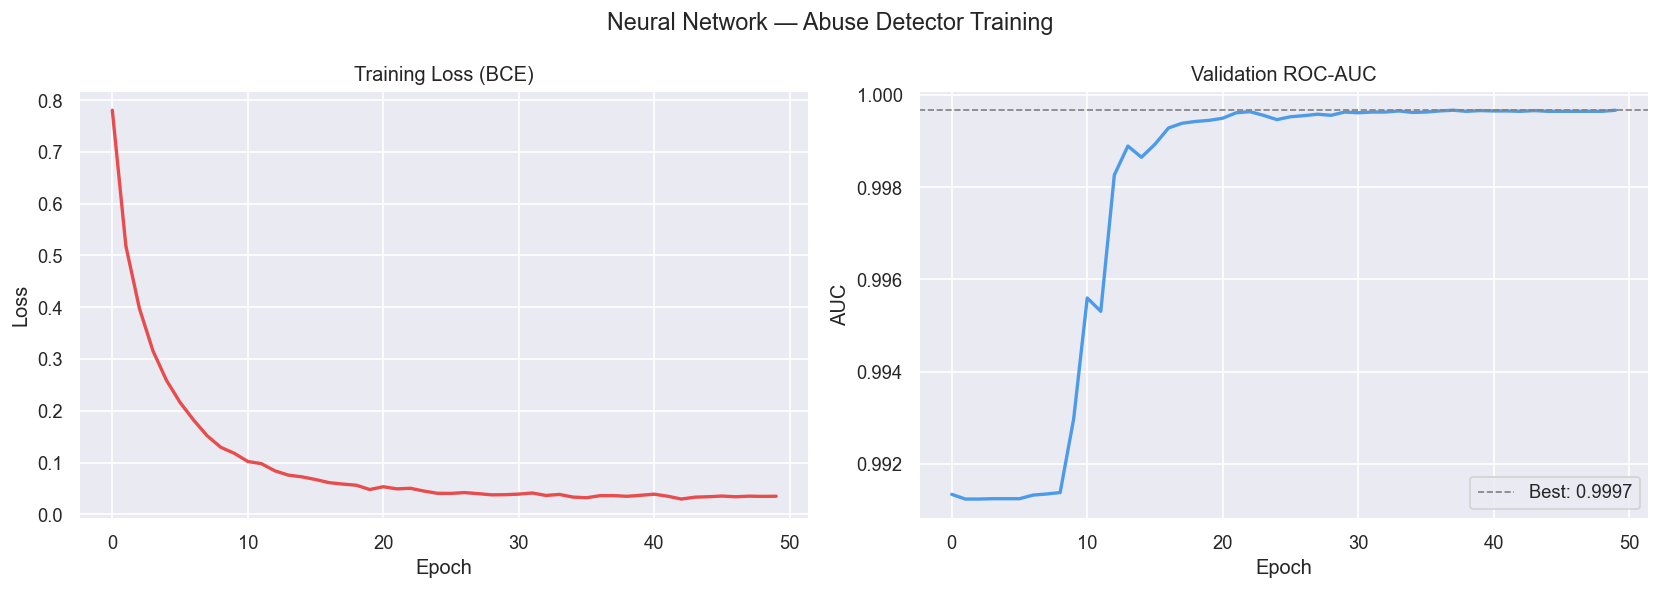

In [23]:
#Plot training loss and validation AUC curves for the neural network
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(train_losses, color='#e84c4c', linewidth=2)
ax1.set_title('Training Loss (BCE)', fontsize=12)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')

ax2.plot(val_aucs, color='#4c9be8', linewidth=2)
ax2.axhline(max(val_aucs), color='gray', linestyle='--', linewidth=1,
            label=f'Best: {max(val_aucs):.4f}')
ax2.set_title('Validation ROC-AUC', fontsize=12)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('AUC')
ax2.legend()

plt.suptitle('Neural Network — Abuse Detector Training', fontsize=14)
plt.tight_layout()

fig.savefig('figures/fig_nn_training.pdf', bbox_inches='tight', dpi=300)
fig.savefig('figures/fig_nn_training.png', bbox_inches='tight', dpi=300)
print("Saved: figures/fig_nn_training.pdf")
display(fig)
plt.close(fig)

Saved: figures/fig_confusion.pdf


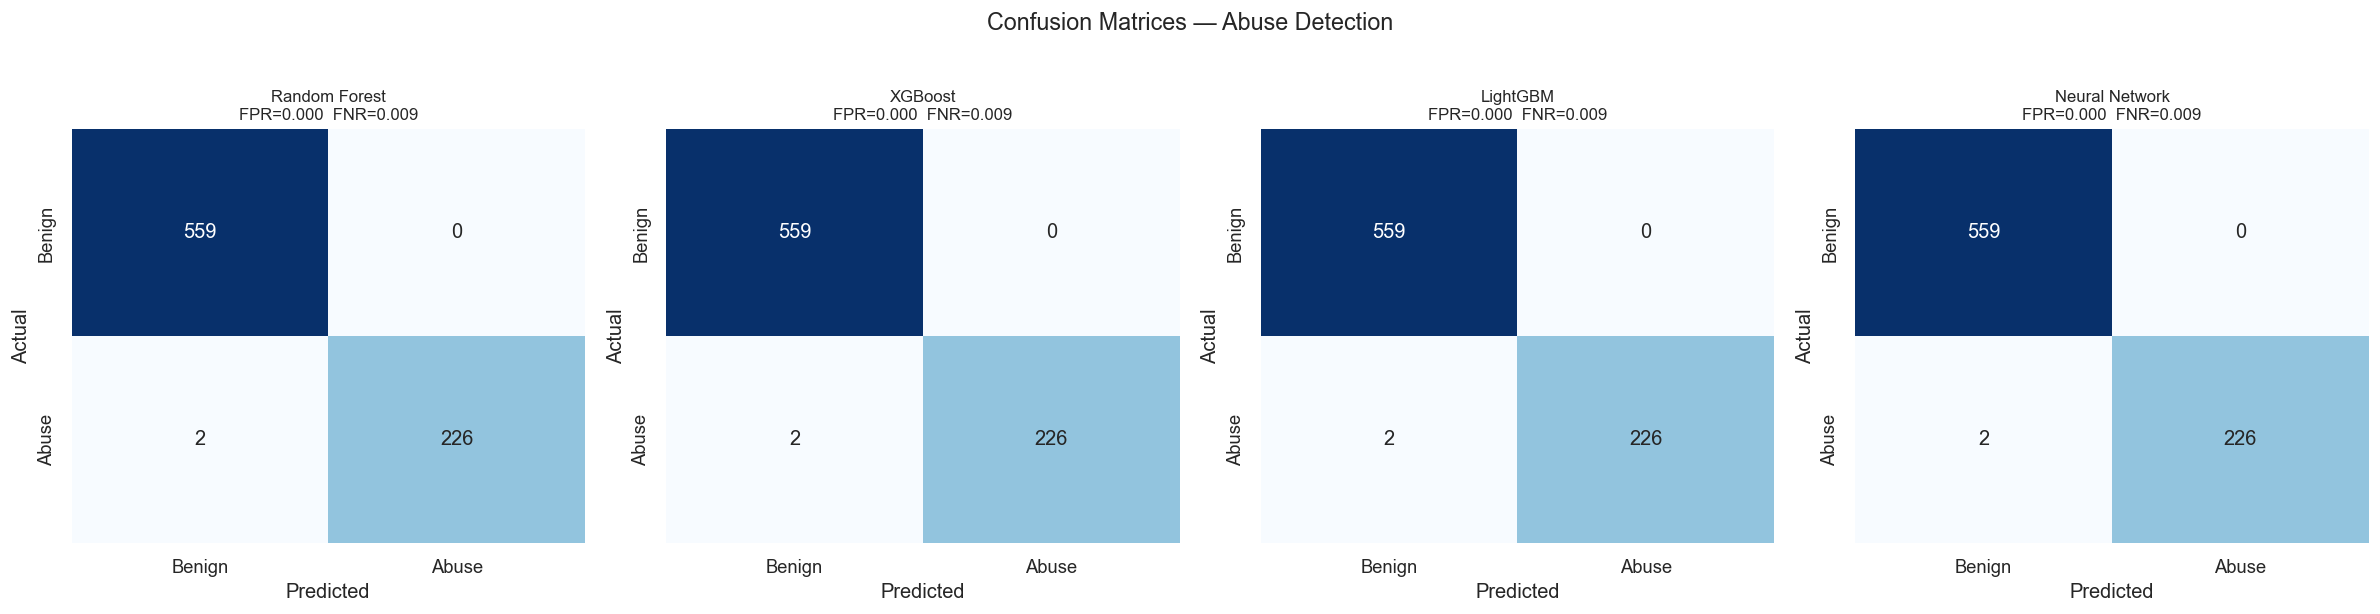

In [24]:
#Confusion matrices for all four classifiers with FPR and FNR annotations
from sklearn.metrics import confusion_matrix

preds_map = {
    'Random Forest': y_pred_rf,
    'XGBoost':       y_pred_xgb,
    'LightGBM':      y_pred_lgb,
    'Neural Network':y_pred_nn,
}

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for ax, (name, preds) in zip(axes, preds_map.items()):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', ax=ax,
                cmap='Blues', cbar=False,
                xticklabels=['Benign', 'Abuse'],
                yticklabels=['Benign', 'Abuse'])
    tn, fp, fn, tp = cm.ravel()
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    fnr = fn / (fn + tp) if (fn + tp) > 0 else 0
    ax.set_title(f'{name}\nFPR={fpr:.3f}  FNR={fnr:.3f}', fontsize=10)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrices — Abuse Detection', fontsize=14, y=1.02)
plt.tight_layout()
fig.savefig('figures/fig_confusion.pdf', bbox_inches='tight', dpi=300)
fig.savefig('figures/fig_confusion.png', bbox_inches='tight', dpi=300)
print("Saved: figures/fig_confusion.pdf")
from IPython.display import display
display(fig)
plt.close(fig)

Saved: figures/fig_roc_curves.pdf


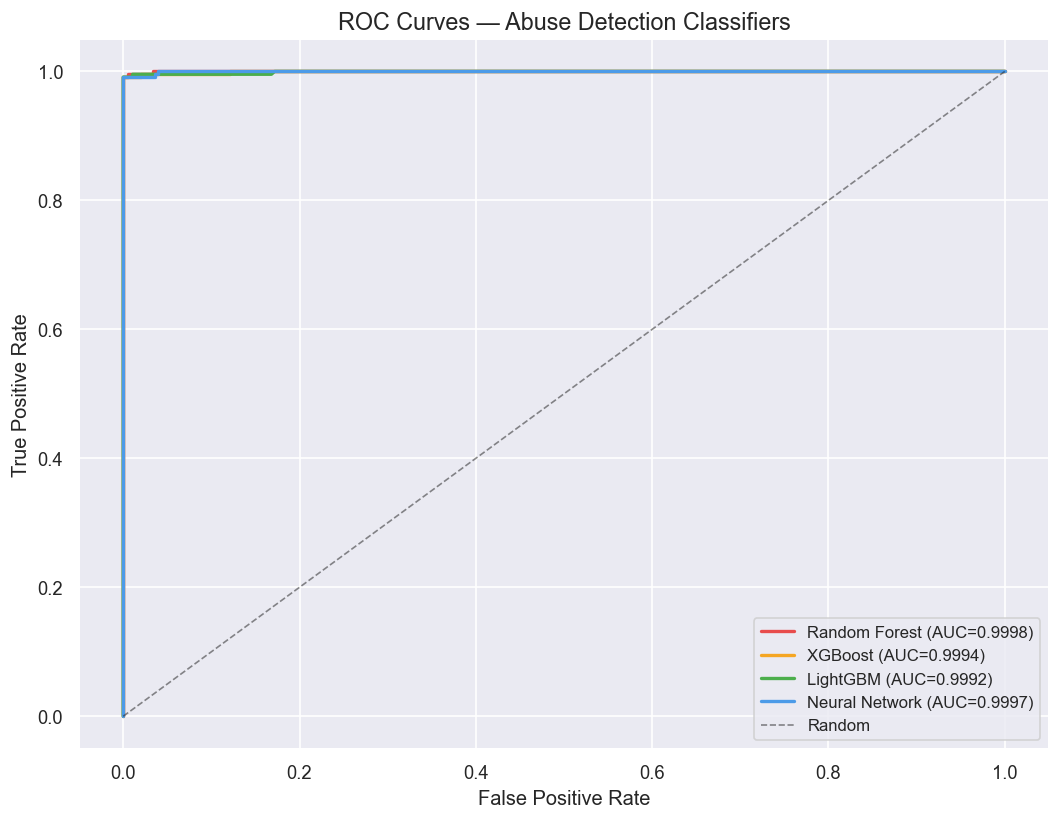

In [25]:
#ROC curves for all classifiers on the held-out test set
from sklearn.metrics import roc_curve

fig, ax = plt.subplots(figsize=(9, 7))

colors = ['#e84c4c', '#f5a623', '#4cae4c', '#4c9be8']
for (name, res), color in zip(results_summary.items(), colors):
    fpr_c, tpr_c, _ = roc_curve(y_test, res['y_prob'])
    ax.plot(fpr_c, tpr_c, linewidth=2, color=color,
            label=f"{name} (AUC={res['roc_auc']:.4f})")

ax.plot([0,1],[0,1], 'k--', linewidth=1, alpha=0.5, label='Random')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves — Abuse Detection Classifiers', fontsize=14)
ax.legend(loc='lower right', fontsize=10)
plt.tight_layout()

fig.savefig('figures/fig_roc_curves.pdf', bbox_inches='tight', dpi=300)
fig.savefig('figures/fig_roc_curves.png', bbox_inches='tight', dpi=300)
print("Saved: figures/fig_roc_curves.pdf")
from IPython.display import display
display(fig)
plt.close(fig)

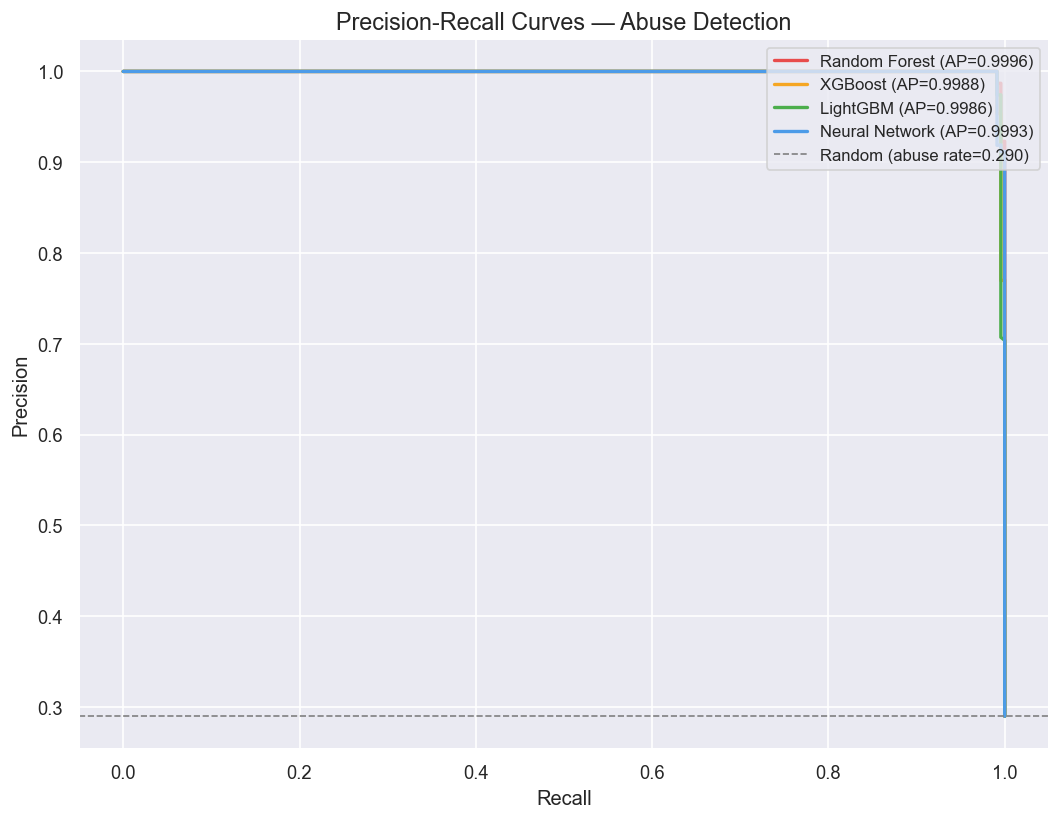

In [26]:
#Precision-recall curves for all classifiers with random baseline
from sklearn.metrics import precision_recall_curve, average_precision_score

fig, ax = plt.subplots(figsize=(9, 7))

colors = ['#e84c4c', '#f5a623', '#4cae4c', '#4c9be8']
for (name, res), color in zip(results_summary.items(), colors):
    prec, rec, _ = precision_recall_curve(y_test, res['y_prob'])
    ap = average_precision_score(y_test, res['y_prob'])
    ax.plot(rec, prec, linewidth=2, color=color,
            label=f"{name} (AP={ap:.4f})")

baseline = y_test.mean()
ax.axhline(baseline, color='gray', linestyle='--', linewidth=1,
           label=f'Random (abuse rate={baseline:.3f})')

ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Precision-Recall Curves — Abuse Detection', fontsize=14)
ax.legend(loc='upper right', fontsize=10)
plt.tight_layout()
plt.show()

Saved: figures/fig_feature_importance.pdf


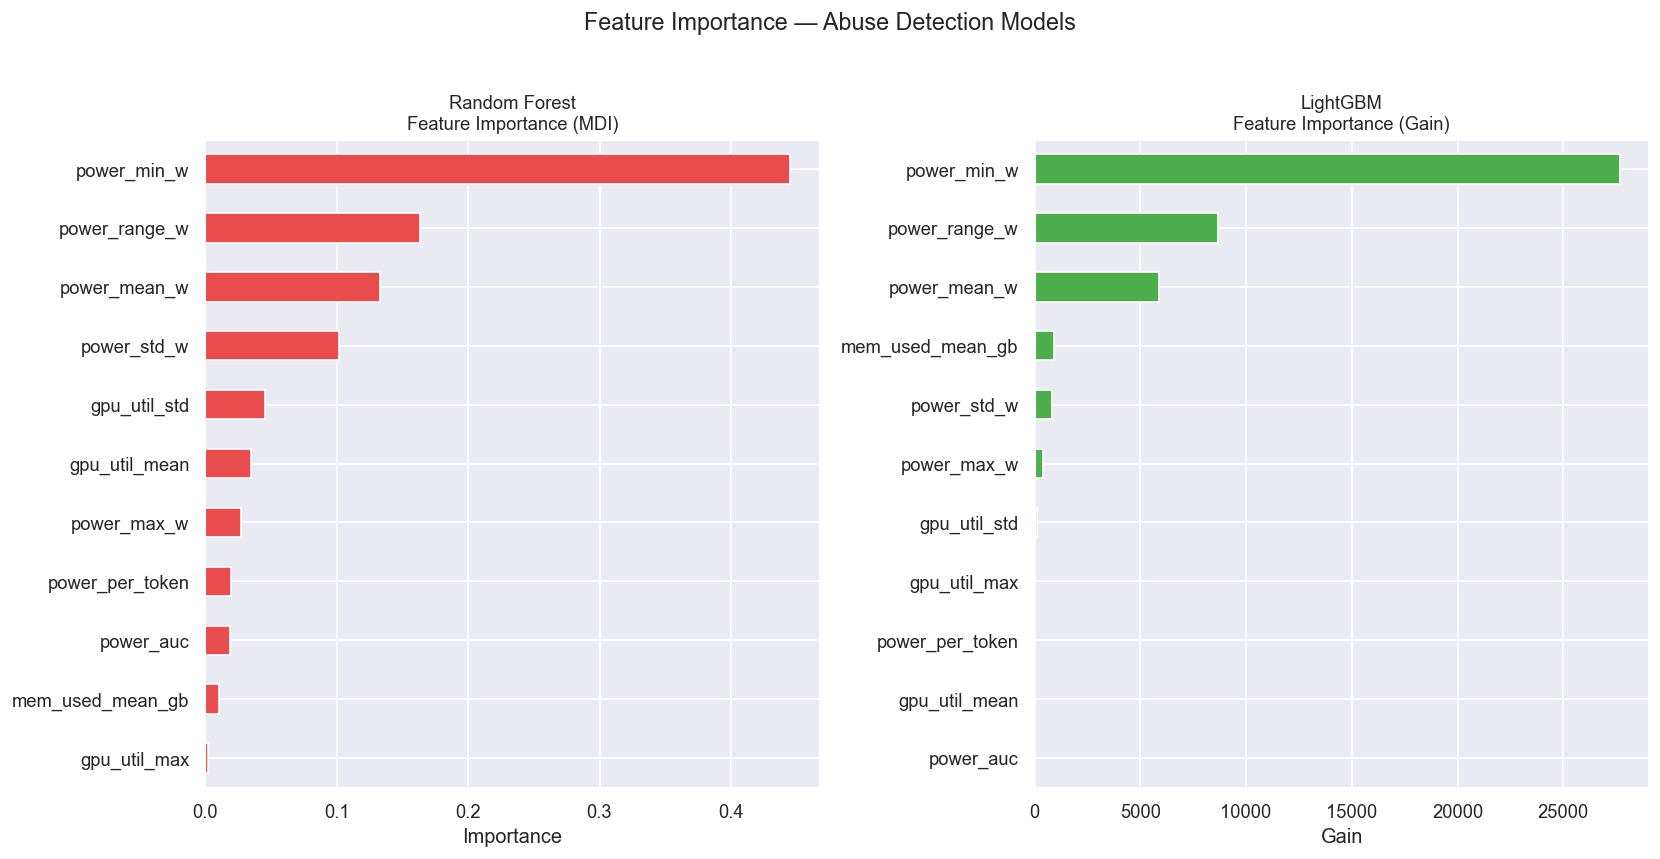

In [27]:
#Feature importance bar charts for Random Forest (MDI) and LightGBM (gain)
plt.close('all')
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

rf_imp = pd.Series(rf.feature_importances_, index=FEATURE_COLS).sort_values()
rf_imp.plot.barh(ax=axes[0], color='#e84c4c')
axes[0].set_title('Random Forest\nFeature Importance (MDI)', fontsize=11)
axes[0].set_xlabel('Importance')

lgb_imp = pd.Series(
    lgb_clf.booster_.feature_importance(importance_type='gain'),
    index=FEATURE_COLS
).sort_values()
lgb_imp.plot.barh(ax=axes[1], color='#4cae4c')
axes[1].set_title('LightGBM\nFeature Importance (Gain)', fontsize=11)
axes[1].set_xlabel('Gain')

plt.suptitle('Feature Importance — Abuse Detection Models', fontsize=14, y=1.02)
plt.tight_layout()

os.makedirs('figures', exist_ok=True)
fig.savefig('figures/fig_feature_importance.pdf', bbox_inches='tight', dpi=300)
fig.savefig('figures/fig_feature_importance.png', bbox_inches='tight', dpi=300)
print("Saved: figures/fig_feature_importance.pdf")

from IPython.display import display
display(fig)
plt.close(fig)

,ROC-AUC,F1,Precision,Recall,FPR,FNR,TP,FP,TN,FN
Model,,,,,,,,,,
Random Forest,0.9998,0.9956,1.0,0.9912,0.0,0.0088,226,0,559,2
XGBoost,0.9994,0.9956,1.0,0.9912,0.0,0.0088,226,0,559,2
LightGBM,0.9992,0.9956,1.0,0.9912,0.0,0.0088,226,0,559,2
Neural Network,0.9997,0.9956,1.0,0.9912,0.0,0.0088,226,0,559,2


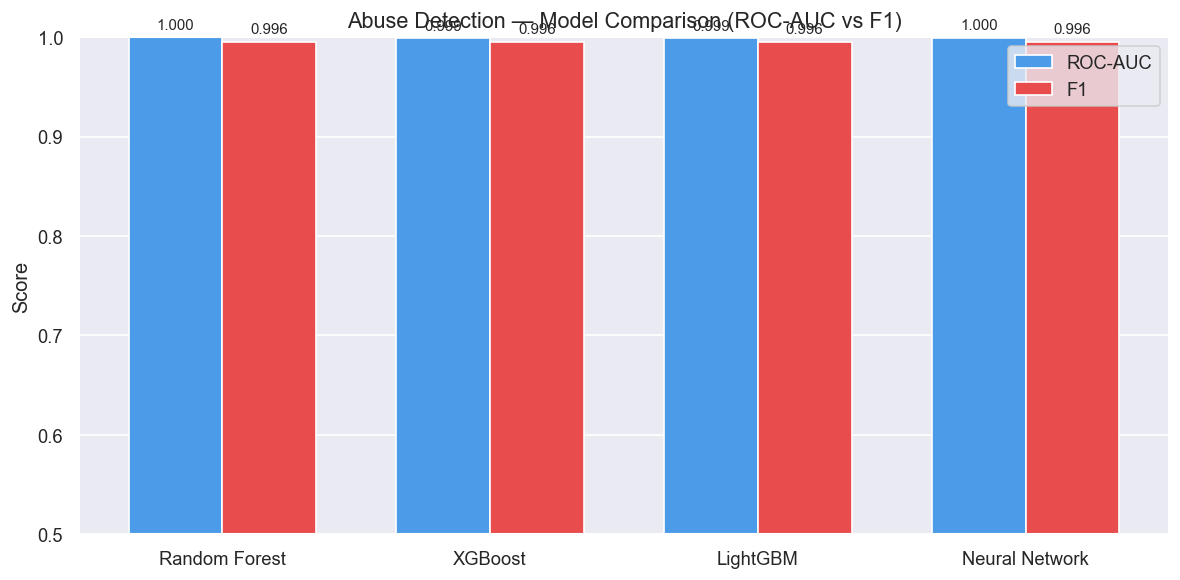


✓ Best model by ROC-AUC: Random Forest (0.9998)
  → FPR=0.0000  FNR=0.0088


In [28]:
#Summary table and bar chart comparing ROC-AUC and F1 across all classifiers
from sklearn.metrics import precision_score, recall_score

all_preds = {
    'Random Forest': y_pred_rf,
    'XGBoost':       y_pred_xgb,
    'LightGBM':      y_pred_lgb,
    'Neural Network':y_pred_nn,
}

rows = []
for name, res in results_summary.items():
    preds = all_preds[name]
    cm = confusion_matrix(y_test, preds)
    tn, fp, fn, tp = cm.ravel()
    rows.append({
        'Model':     name,
        'ROC-AUC':   round(res['roc_auc'], 4),
        'F1':        round(res['f1'], 4),
        'Precision': round(precision_score(y_test, preds), 4),
        'Recall':    round(recall_score(y_test, preds), 4),
        'FPR':       round(fp / (fp + tn), 4),
        'FNR':       round(fn / (fn + tp), 4),
        'TP': tp, 'FP': fp, 'TN': tn, 'FN': fn
    })

summary = pd.DataFrame(rows).set_index('Model')
display(summary)

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(summary))
w = 0.35
bars1 = ax.bar(x - w/2, summary['ROC-AUC'], w, label='ROC-AUC', color='#4c9be8')
bars2 = ax.bar(x + w/2, summary['F1'],      w, label='F1',      color='#e84c4c')
ax.set_xticks(x)
ax.set_xticklabels(summary.index, fontsize=11)
ax.set_ylim(0.5, 1.0)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Abuse Detection — Model Comparison (ROC-AUC vs F1)', fontsize=13)
ax.legend()
for bar in list(bars1) + list(bars2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

best_model = summary['ROC-AUC'].idxmax()
print(f'\n✓ Best model by ROC-AUC: {best_model} ({summary.loc[best_model, "ROC-AUC"]:.4f})')
print(f'  → FPR={summary.loc[best_model, "FPR"]:.4f}  FNR={summary.loc[best_model, "FNR"]:.4f}')

In [29]:
#Cross-model holdout: train on 2 models, test on the 3rd to measure generalization
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, classification_report, f1_score
import pandas as pd

models_available = list(model_dfs.keys())
print(f'Models available for holdout: {models_available}')
print(f'Active feature set: {ACTIVE_FEATURE_SET}')
print(f'Features ({len(FEATURE_COLS)}): {FEATURE_COLS}')
print()

holdout_results = []

for holdout_model in models_available:
    train_models = [m for m in models_available if m != holdout_model]
    train_df = pd.concat([model_dfs[m] for m in train_models], ignore_index=True)
    test_df  = model_dfs[holdout_model].copy()

    for df in [train_df, test_df]:
        if 'tokens_per_sec' not in df.columns:
            df['tokens_per_sec'] = df['tokens_out'] / df['latency_s'].replace(0, float('nan'))
        if 'power_range_w' not in df.columns:
            df['power_range_w'] = df['power_max_w'] - df['power_min_w']
        if 'model_enc' not in df.columns:
            from sklearn.preprocessing import LabelEncoder
            _le = LabelEncoder()
            df['model_enc'] = _le.fit_transform(df['model_name'])

    available_feats = [c for c in FEATURE_COLS if c in train_df.columns and c in test_df.columns]
    train_clean = train_df[available_feats + ['label']].dropna()
    test_clean  = test_df[available_feats  + ['label']].dropna()

    X_tr = train_clean[available_feats].values
    y_tr = train_clean['label'].values
    X_te = test_clean[available_feats].values
    y_te = test_clean['label'].values

    clf = RandomForestClassifier(
        n_estimators=300, min_samples_leaf=5,
        class_weight='balanced', n_jobs=-1, random_state=42
    )
    clf.fit(X_tr, y_tr)
    y_prob = clf.predict_proba(X_te)[:, 1]
    y_pred = clf.predict(X_te)

    auc = roc_auc_score(y_te, y_prob)
    f1  = f1_score(y_te, y_pred)

    holdout_results.append({
        'Holdout Model':    holdout_model.upper(),
        'Train Models':     '+'.join(m.upper() for m in train_models),
        'Train N':          len(y_tr),
        'Test N':           len(y_te),
        'Train Abuse Rate': round(y_tr.mean(), 3),
        'Test Abuse Rate':  round(y_te.mean(), 3),
        'ROC-AUC':          round(auc, 4),
        'F1':               round(f1, 4),
    })

    print(f'Holdout: {holdout_model.upper():6s} | train={len(y_tr):,} | test={len(y_te):,} | '
          f'AUC={auc:.4f} | F1={f1:.4f}')
    print(classification_report(y_te, y_pred, target_names=['Benign','Abuse'], digits=4))

holdout_df = pd.DataFrame(holdout_results)
print('\n=== CROSS-MODEL HOLDOUT SUMMARY ===')
display(holdout_df.set_index('Holdout Model'))

mean_auc = holdout_df['ROC-AUC'].mean()
std_auc  = holdout_df['ROC-AUC'].std()
print(f'\nMean holdout AUC: {mean_auc:.4f} ± {std_auc:.4f}')
print()
if mean_auc >= 0.90:
    print('✓ Strong cross-architecture generalization. Power signal is model-agnostic.')
elif mean_auc >= 0.75:
    print('~ Moderate generalization. Signal exists but varies across model families.')
else:
    print('⚠ Weak generalization. Signal is model-specific.')

if results_summary:
    rand_split_auc = results_summary.get('Random Forest', {}).get('roc_auc', None)
    if rand_split_auc:
        gap = rand_split_auc - mean_auc
        print(f'\nRandom-split AUC (Cell 24): {rand_split_auc:.4f}')
        print(f'Cross-model holdout AUC   : {mean_auc:.4f}')
        print(f'Optimism gap              : {gap:+.4f}')
        if gap > 0.05:
            print('  ⚠ Gap >0.05 — random split was optimistic. Use holdout AUC in paper.')
        else:
            print('  ✓ Gap <0.05 — random split was representative.')

Models available for holdout: ['llama', 'phi', 'qwen']
Active feature set: telemetry_only
Features (11): ['power_mean_w', 'power_max_w', 'power_min_w', 'power_std_w', 'power_auc', 'power_per_token', 'power_range_w', 'gpu_util_mean', 'gpu_util_max', 'gpu_util_std', 'mem_used_mean_gb']

Holdout: LLAMA  | train=2,642 | test=1,289 | AUC=0.9988 | F1=0.9925
              precision    recall  f1-score   support

      Benign     0.9948    1.0000    0.9974       952
       Abuse     1.0000    0.9852    0.9925       337

    accuracy                         0.9961      1289
   macro avg     0.9974    0.9926    0.9950      1289
weighted avg     0.9961    0.9961    0.9961      1289

Holdout: PHI    | train=2,687 | test=1,244 | AUC=1.0000 | F1=0.9975
              precision    recall  f1-score   support

      Benign     0.9988    0.9988    0.9988       844
       Abuse     0.9975    0.9975    0.9975       400

    accuracy                         0.9984      1244
   macro avg     0.9982    0.9982

,Train Models,Train N,Test N,Train Abuse Rate,Test Abuse Rate,ROC-AUC,F1
Holdout Model,,,,,,,
LLAMA,PHI+QWEN,2642,1289,0.303,0.261,0.9988,0.9925
PHI,LLAMA+QWEN,2687,1244,0.274,0.322,1.0000,0.9975
QWEN,LLAMA+PHI,2533,1398,0.291,0.286,0.9994,0.8966



Mean holdout AUC: 0.9994 ± 0.0006

✓ Strong cross-architecture generalization. Power signal is model-agnostic.

Random-split AUC (Cell 24): 0.9998
Cross-model holdout AUC   : 0.9994
Optimism gap              : +0.0004
  ✓ Gap <0.05 — random split was representative.


In [30]:
#Compute power/energy cost difference between abuse and benign requests, with at-scale projections
print('=' * 65)
print('POWER COST: ABUSE vs BENIGN')
print('=' * 65)

power_cols = ['power_mean_w', 'power_auc', 'power_per_token', 'latency_s']

for model_name, df in model_dfs.items():
    b = df[df['label']==0]
    a = df[df['label']==1]
    print(f'\n{model_name.upper()}')
    print(f'  {"Metric":<22} {"Benign":>10} {"Abuse":>10} {"Delta":>10} {"% Increase":>12}')
    print(f'  {"-"*22} {"-"*10} {"-"*10} {"-"*10} {"-"*12}')
    for col in power_cols:
        if col not in df.columns: continue
        bm = b[col].mean()
        am = a[col].mean()
        delta = am - bm
        pct   = (delta / bm) * 100 if bm != 0 else float('nan')
        print(f'  {col:<22} {bm:>10.3f} {am:>10.3f} {delta:>+10.3f} {pct:>11.1f}%')

print('\n' + '=' * 65)
print('ENERGY PER REQUEST (Joules = power_mean_w × latency_s)')
print('=' * 65)
print(f'\n  {"Model":<8} {"Benign J":>10} {"Abuse J":>10} {"Delta J":>10} {"% More Energy":>14}')
print(f'  {"-"*8} {"-"*10} {"-"*10} {"-"*10} {"-"*14}')

total_b_j, total_a_j = [], []
for model_name, df in model_dfs.items():
    df = df.copy()
    df['energy_j'] = df['power_mean_w'] * df['latency_s']
    b_j = df[df['label']==0]['energy_j'].mean()
    a_j = df[df['label']==1]['energy_j'].mean()
    pct = ((a_j - b_j) / b_j) * 100
    print(f'  {model_name.upper():<8} {b_j:>10.3f} {a_j:>10.3f} {a_j-b_j:>+10.3f} {pct:>13.1f}%')
    total_b_j.append(b_j)
    total_a_j.append(a_j)

avg_b = np.mean(total_b_j)
avg_a = np.mean(total_a_j)
avg_pct = ((avg_a - avg_b) / avg_b) * 100
print(f'\n  {"MEAN":<8} {avg_b:>10.3f} {avg_a:>10.3f} {avg_a-avg_b:>+10.3f} {avg_pct:>13.1f}%')
print(f'\n  → On average, abuse requests consume {avg_pct:+.1f}% more energy than benign.')

print('\n' + '=' * 65)
print('AT-SCALE PROJECTION')
print('=' * 65)
for daily_requests in [10_000, 100_000, 1_000_000]:
    for abuse_rate in [0.01, 0.05, 0.10]:
        n_abuse  = int(daily_requests * abuse_rate)
        n_benign = daily_requests - n_abuse
        daily_j  = (n_benign * avg_b) + (n_abuse * avg_a)
        baseline_j = daily_requests * avg_b
        overhead_j = daily_j - baseline_j
        overhead_wh = overhead_j / 3600
        print(f'  {daily_requests:>10,} req/day | {abuse_rate:.0%} abuse → '
              f'overhead={overhead_j:>10,.1f} J/day  ({overhead_wh:>7.2f} Wh/day)')

POWER COST: ABUSE vs BENIGN

LLAMA
  Metric                     Benign      Abuse      Delta   % Increase
  ---------------------- ---------- ---------- ---------- ------------
  power_mean_w              156.566    245.543    +88.977        56.8%
  power_auc                 994.016   1128.123   +134.107        13.5%
  power_per_token             4.178      4.770     +0.592        14.2%
  latency_s                   0.733      0.546     -0.187       -25.6%

PHI
  Metric                     Benign      Abuse      Delta   % Increase
  ---------------------- ---------- ---------- ---------- ------------
  power_mean_w              232.786    279.679    +46.894        20.1%
  power_auc                5483.879   5598.932   +115.053         2.1%
  power_per_token           644.367     22.818   -621.549       -96.5%
  latency_s                   4.430      2.340     -2.090       -47.2%

QWEN
  Metric                     Benign      Abuse      Delta   % Increase
  ---------------------- ------

In [31]:
#Load qwen_wild test CSVs and combine with labels for out-of-distribution evaluation
import pandas as pd

TEST_DIR = 'qwen_test_logs/'

df_abuse  = pd.read_csv(f'{TEST_DIR}telemetry_20260312_160006_abuse.csv')
df_benign = pd.read_csv(f'{TEST_DIR}telemetry_20260313_130605_benign.csv')

df_abuse['label']      = 1
df_benign['label']     = 0
df_abuse['label_str']  = 'abuse'
df_benign['label_str'] = 'benign'

df_wild = pd.concat([df_abuse, df_benign], ignore_index=True)
df_wild['model_name'] = 'qwen'

print(f'abuse  rows : {len(df_abuse):,}')
print(f'benign rows : {len(df_benign):,}')
print(f'total  rows : {len(df_wild):,}')
print(f'label balance: {df_wild["label"].value_counts().to_dict()}')
print(f'model values: {df_wild["model"].unique()}')
print(f'model_name mapped to: {df_wild["model_name"].unique()}')

abuse  rows : 8,195
benign rows : 8,000
total  rows : 16,195
label balance: {1: 8195, 0: 8000}
model values: <ArrowStringArray>
['qwen_wild']
Length: 1, dtype: str
model_name mapped to: <ArrowStringArray>
['qwen']
Length: 1, dtype: str


In [32]:
#Add derived features and encode model name for qwen_wild using training LabelEncoder
from sklearn.preprocessing import LabelEncoder

df_wild['tokens_per_sec'] = df_wild['tokens_out'] / df_wild['latency_s'].replace(0, float('nan'))
df_wild['power_range_w']  = df_wild['power_max_w'] - df_wild['power_min_w']

le = LabelEncoder()
le.fit(sorted(df_all['model_name'].unique()))
print(f'LabelEncoder classes: {list(le.classes_)}')

df_wild['model_enc'] = le.transform(df_wild['model_name'])

available_feats = [c for c in FEATURE_COLS if c in df_wild.columns]
missing_feats   = [c for c in FEATURE_COLS if c not in df_wild.columns]

print(f'FEATURE_COLS expected : {len(FEATURE_COLS)}')
print(f'Available in df_wild  : {len(available_feats)}')
if missing_feats:
    print(f'MISSING — will break classifier: {missing_feats}')
else:
    print('All features present ✓')

df_wild_ml = df_wild[available_feats + ['label']].dropna().copy()
X_wild     = df_wild_ml[available_feats].values
y_wild     = df_wild_ml['label'].values

print(f'\nClean rows for inference : {len(X_wild):,}')
print(f'Dropped (NaN)            : {len(df_wild) - len(X_wild):,}')
print(f'Label balance            : benign={(y_wild==0).sum():,}  abuse={(y_wild==1).sum():,}')

LabelEncoder classes: [np.str_('llama'), np.str_('phi'), np.str_('qwen')]
FEATURE_COLS expected : 11
Available in df_wild  : 11
All features present ✓

Clean rows for inference : 16,195
Dropped (NaN)            : 0
Label balance            : benign=8,000  abuse=8,195


In [33]:
#Rebuild derived features and re-encode model using existing LabelEncoder
df_wild['tokens_per_sec'] = df_wild['tokens_out'] / df_wild['latency_s'].replace(0, float('nan'))
df_wild['power_range_w']  = df_wild['power_max_w'] - df_wild['power_min_w']

df_wild['model_enc'] = le.transform(df_wild['model_name'])

available_feats = [c for c in FEATURE_COLS if c in df_wild.columns]
missing_feats   = [c for c in FEATURE_COLS if c not in df_wild.columns]

print(f'FEATURE_COLS expected : {len(FEATURE_COLS)}')
print(f'Available in df_wild  : {len(available_feats)}')
if missing_feats:
    print(f'MISSING — will break classifier: {missing_feats}')
else:
    print('All features present ✓')

df_wild_ml = df_wild[available_feats + ['label']].dropna().copy()
X_wild     = df_wild_ml[available_feats].values
y_wild     = df_wild_ml['label'].values

print(f'\nClean rows for inference : {len(X_wild):,}')
print(f'Dropped (NaN)            : {len(df_wild) - len(X_wild):,}')
print(f'Label balance            : benign={(y_wild==0).sum():,}  abuse={(y_wild==1).sum():,}')

FEATURE_COLS expected : 11
Available in df_wild  : 11
All features present ✓

Clean rows for inference : 16,195
Dropped (NaN)            : 0
Label balance            : benign=8,000  abuse=8,195


In [34]:
#Evaluate all classifiers on qwen_wild and compare to original random-split results
from sklearn.metrics import roc_auc_score, classification_report, f1_score, confusion_matrix

print(f'Evaluating on qwen_wild | n={len(X_wild):,} | feature set: {ACTIVE_FEATURE_SET}')
print(f'Label balance: benign={(y_wild==0).sum():,}  abuse={(y_wild==1).sum():,}')
print()

wild_results = {}

classifiers = {
    'Random Forest': (rf,       X_wild),
    'XGBoost':       (xgb_clf,  X_wild),
    'LightGBM':      (lgb_clf,  X_wild),
}

for name, (clf, X_in) in classifiers.items():
    y_prob = clf.predict_proba(X_in)[:, 1]
    y_pred = clf.predict(X_in)
    auc    = roc_auc_score(y_wild, y_prob)
    f1     = f1_score(y_wild, y_pred)
    cm     = confusion_matrix(y_wild, y_pred)
    tn, fp, fn, tp = cm.ravel()

    wild_results[name] = {'roc_auc': auc, 'f1': f1, 'y_prob': y_prob,
                          'TP': tp, 'FP': fp, 'TN': tn, 'FN': fn}

    print(f'=== {name} ===')
    print(classification_report(y_wild, y_pred, target_names=['Benign','Abuse'], digits=4))
    print(f'ROC-AUC: {auc:.4f}  |  FPR: {fp/(fp+tn):.4f}  |  FNR: {fn/(fn+tp):.4f}')
    print()

X_wild_sc  = scaler.transform(X_wild)
X_wild_t   = torch.tensor(X_wild_sc, dtype=torch.float32)
model_nn.eval()
with torch.no_grad():
    logits = model_nn(X_wild_t.to('cuda' if torch.cuda.is_available() else 'cpu')).cpu().numpy()
y_prob_nn = torch.sigmoid(torch.tensor(logits)).numpy()
y_pred_nn = (y_prob_nn >= 0.5).astype(int)
auc_nn    = roc_auc_score(y_wild, y_prob_nn)
f1_nn     = f1_score(y_wild, y_pred_nn)
cm_nn     = confusion_matrix(y_wild, y_pred_nn)
tn, fp, fn, tp = cm_nn.ravel()

wild_results['Neural Network'] = {'roc_auc': auc_nn, 'f1': f1_nn, 'y_prob': y_prob_nn,
                                   'TP': tp, 'FP': fp, 'TN': tn, 'FN': fn}

print('=== Neural Network ===')
print(classification_report(y_wild, y_pred_nn, target_names=['Benign','Abuse'], digits=4))
print(f'ROC-AUC: {auc_nn:.4f}  |  FPR: {fp/(fp+tn):.4f}  |  FNR: {fn/(fn+tp):.4f}')

print()
print('=== QWEN WILD vs ORIGINAL RANDOM SPLIT (Random Forest) ===')
print(f'{"Metric":<12} {"Original":>10} {"qwen_wild":>10} {"Delta":>10}')
print('-' * 44)
for metric in ['roc_auc', 'f1']:
    orig = results_summary.get('Random Forest', {}).get(metric, float('nan'))
    wild = wild_results['Random Forest'][metric]
    print(f'{metric:<12} {orig:>10.4f} {wild:>10.4f} {wild-orig:>+10.4f}')

Evaluating on qwen_wild | n=16,195 | feature set: telemetry_only
Label balance: benign=8,000  abuse=8,195

=== Random Forest ===
              precision    recall  f1-score   support

      Benign     0.7558    0.0081    0.0161      8000
       Abuse     0.5074    0.9974    0.6726      8195

    accuracy                         0.5087     16195
   macro avg     0.6316    0.5028    0.3444     16195
weighted avg     0.6301    0.5087    0.3483     16195

ROC-AUC: 0.7803  |  FPR: 0.9919  |  FNR: 0.0026

=== XGBoost ===
              precision    recall  f1-score   support

      Benign     0.8173    0.0106    0.0210      8000
       Abuse     0.5081    0.9977    0.6733      8195

    accuracy                         0.5101     16195
   macro avg     0.6627    0.5042    0.3471     16195
weighted avg     0.6608    0.5101    0.3511     16195

ROC-AUC: 0.7106  |  FPR: 0.9894  |  FNR: 0.0023

=== LightGBM ===
              precision    recall  f1-score   support

      Benign     0.8116    0.00

Saved: figures/fig_wild_power_kde.pdf


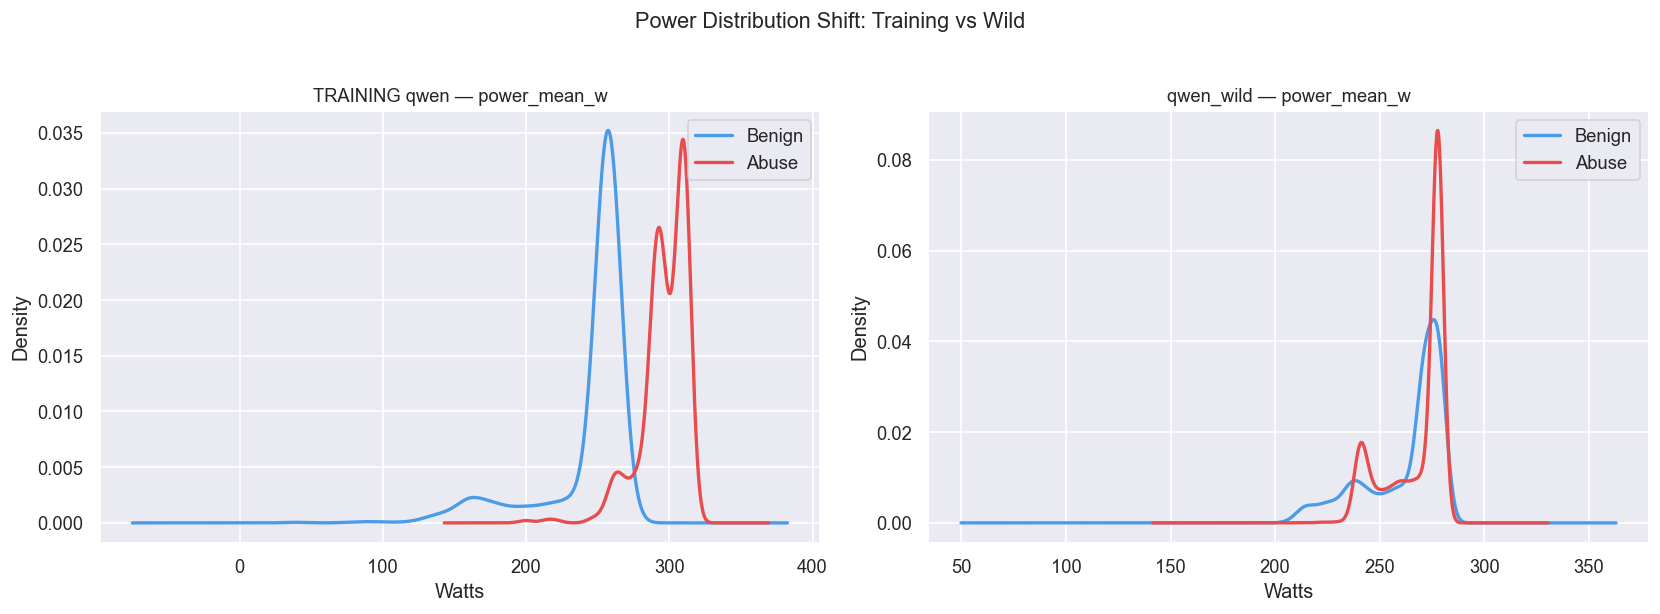

=== POWER MEAN COMPARISON ===
Source               Label       power_mean_w μ  power_mean_w σ
--------------------------------------------------------------
qwen_train           benign             243.395          32.296
qwen_wild            benign             262.489          19.027

qwen_train           abuse              296.713          16.009
qwen_wild            abuse              267.997          14.170



In [35]:
#KDE comparison of power_mean_w between training qwen and qwen_wild datasets
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

qwen_train = model_dfs['qwen']
for label, color, name in [(0,'#4c9be8','Benign'),(1,'#e84c4c','Abuse')]:
    vals = qwen_train[qwen_train['label']==label]['power_mean_w'].dropna()
    vals.plot.kde(ax=axes[0], color=color, linewidth=2, label=name)
axes[0].set_title('TRAINING qwen — power_mean_w', fontsize=11)
axes[0].set_xlabel('Watts')
axes[0].legend()

for label, color, name in [(0,'#4c9be8','Benign'),(1,'#e84c4c','Abuse')]:
    vals = df_wild[df_wild['label']==label]['power_mean_w'].dropna()
    vals.plot.kde(ax=axes[1], color=color, linewidth=2, label=name)
axes[1].set_title('qwen_wild — power_mean_w', fontsize=11)
axes[1].set_xlabel('Watts')
axes[1].legend()

plt.suptitle('Power Distribution Shift: Training vs Wild', fontsize=13, y=1.02)
plt.tight_layout()
os.makedirs('figures', exist_ok=True)
fig.savefig('figures/fig_wild_power_kde.pdf', bbox_inches='tight', dpi=300)
fig.savefig('figures/fig_wild_power_kde.png', bbox_inches='tight', dpi=300)
print("Saved: figures/fig_wild_power_kde.pdf")
from IPython.display import display
display(fig)
plt.close(fig)

print('=== POWER MEAN COMPARISON ===')
print(f'{"Source":<20} {"Label":<10} {"power_mean_w μ":>15} {"power_mean_w σ":>15}')
print('-' * 62)
for label, name in [(0,'benign'),(1,'abuse')]:
    t = qwen_train[qwen_train['label']==label]['power_mean_w'].dropna()
    w = df_wild[df_wild['label']==label]['power_mean_w'].dropna()
    print(f'{"qwen_train":<20} {name:<10} {t.mean():>15.3f} {t.std():>15.3f}')
    print(f'{"qwen_wild":<20} {name:<10} {w.mean():>15.3f} {w.std():>15.3f}')
    print()

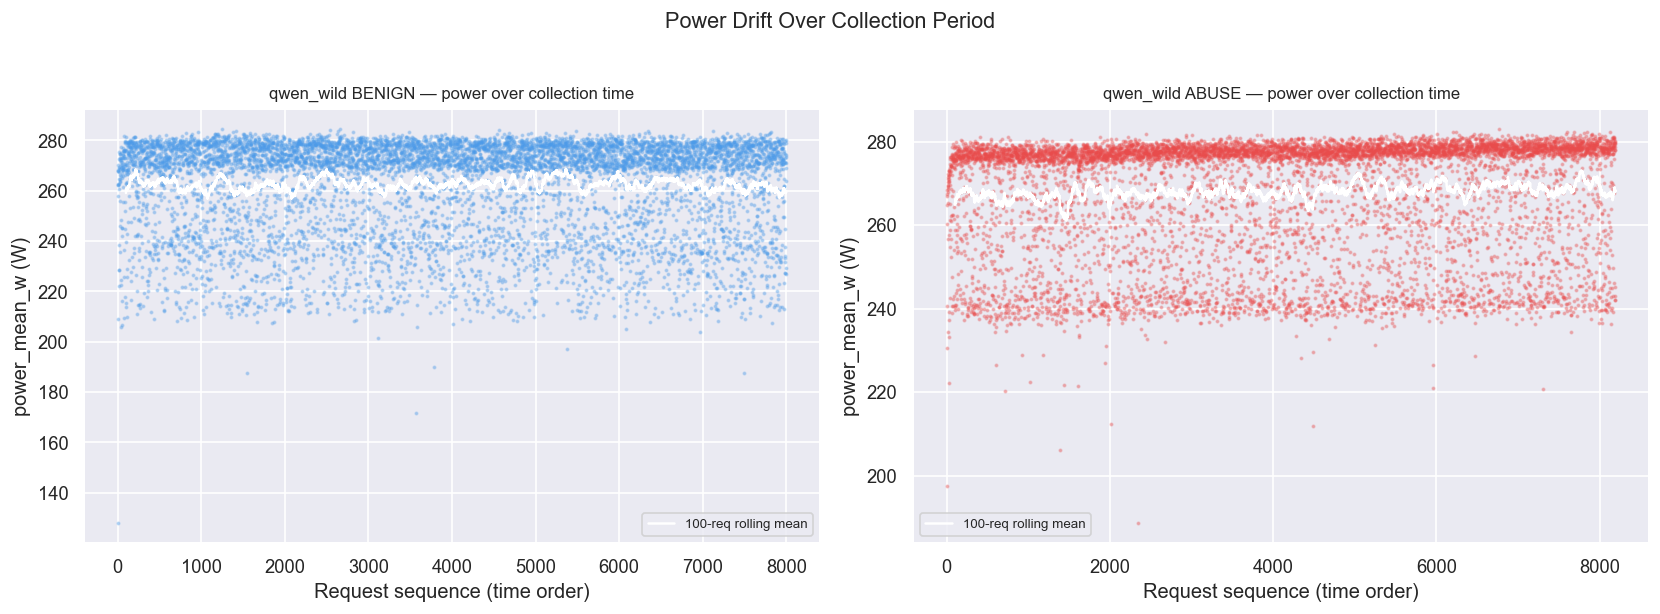

=== qwen_wild BENIGN power_mean_w percentiles ===
  Pct        Benign      Abuse
  ------ ---------- ----------
  5         221.750    240.003
  10        232.360    242.111
  25        251.133    258.817
  50        270.881    276.301
  75        276.637    278.050
  90        279.152    279.200
  95        280.162    279.870
  99        281.842    280.890


In [36]:
#Scatter power_mean_w over request sequence to detect temporal drift, with percentile breakdown
import matplotlib.pyplot as plt
import pandas as pd

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (df, title) in zip(axes, [
    (df_wild[df_wild['label']==0], 'qwen_wild BENIGN — power over collection time'),
    (df_wild[df_wild['label']==1], 'qwen_wild ABUSE — power over collection time'),
]):
    ax.scatter(range(len(df)), df['power_mean_w'].values,
               s=2, alpha=0.3, color='#4c9be8' if 'BENIGN' in title else '#e84c4c')
    ax.set_xlabel('Request sequence (time order)')
    ax.set_ylabel('power_mean_w (W)')
    ax.set_title(title, fontsize=10)
    roll = pd.Series(df['power_mean_w'].values).rolling(100).mean()
    ax.plot(roll.values, color='white', linewidth=1.5, label='100-req rolling mean')
    ax.legend(fontsize=8)

plt.suptitle('Power Drift Over Collection Period', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print('=== qwen_wild BENIGN power_mean_w percentiles ===')
pcts = [5, 10, 25, 50, 75, 90, 95, 99]
b = df_wild[df_wild['label']==0]['power_mean_w'].dropna()
a = df_wild[df_wild['label']==1]['power_mean_w'].dropna()
print(f'  {"Pct":<6} {"Benign":>10} {"Abuse":>10}')
print(f'  {"-"*6} {"-"*10} {"-"*10}')
for p in pcts:
    print(f'  {p:<6} {b.quantile(p/100):>10.3f} {a.quantile(p/100):>10.3f}')